# MindReader Clinical Trial Study & Pipeline Comparison Prototype

This notebook demonstrates how MindReader can convert raw clinical trial registry data into structured, normalized, weighted, and explainable study/pipeline comparisons.

The goal is not to build a chatbot yet. The goal is to prove that we can compare clinical studies and pipelines on clinically meaningful dimensions such as efficacy, safety, tolerability, patient convenience, endpoint quality, cost/access, regulatory maturity, and pipeline strength.

This notebook is designed for approval. After approval, the method can be converted into a repeatable product pipeline.


## Why This Matters

Clinical trial records are difficult to compare manually because each study may have different endpoints, populations, phases, sponsors, results availability, safety signals, and design choices.

MindReader’s value is to convert these scattered fields into structured intelligence:
- What looks clinically meaningful?
- What looks safe or risky?
- Which therapy is easier for patients?
- Which pipeline looks more mature?
- Which studies have stronger evidence?
- Where is data missing?


# Final Notebook Direction

This notebook is not trying to predict clinical success.

It is building an explainable clinical-trial intelligence method that compares studies based on available structured evidence.

The method separates:

1. Clinical & Pipeline Significance Score  
   A normalized weighted comparison score.

2. Data Confidence Score  
   A measure of how complete the available evidence is.

3. AI Trial Intelligence Card  
   A source-grounded explanation of strengths, risks, missing evidence, and what users should not conclude.

This keeps the system transparent and avoids overclaiming.


In [1]:
import os
import glob
import json
import math
import urllib.request
import urllib.parse
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, RobustScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 160)
sns.set_theme(style='whitegrid')


In [2]:
def find_clinical_trials_csv():
    preferred = 'clinical_trials(1).csv'
    if os.path.exists(preferred):
        return preferred

    candidates = glob.glob('*clinical_trials*.csv')
    if not candidates:
        raise FileNotFoundError('No clinical trial CSV found in current directory.')
    return candidates[0]

csv_path = find_clinical_trials_csv()
df = pd.read_csv(csv_path)

print('Loaded:', csv_path)
print('Shape:', df.shape)
display(df.head())
display(df.isna().sum().sort_values(ascending=False))


Loaded: clinical_trials.csv
Shape: (7000, 12)


,nct_id,brief_title,official_title,category,status,start_date,completion_date,sponsor,study_type,phase,enrollment,conditions
0,NCT04799925,Hyperuricemia and Diabetic Nephropathy,Effect of Treatment of Hyperuricemia on Progression of Diabetic Nephropathy in Patients With Type II Diabetes Mellitus and Stage III Chronic Kidney Disease.,Autoimmune,UNKNOWN,2021-04-15,2022-12-30,Assiut University,OBSERVATIONAL,NaN,200,"Hyperuricemia, Diabetic Nephropathies"
1,NCT05132725,Carbohydrate Counting and DASH Intervention Among Children With Diabetes and Celiac Disease.,Studying the Effect of Gluten Free Diet Alone Versus Combination of Gluten Free Diet With Either Carbohydrate Count or Dietary Approach to Reduce Hypertensi...,Autoimmune,UNKNOWN,2021-11-15,2022-11-11,University of Jordan,INTERVENTIONAL,NaN,45,"Diabetes Mellitus, Type 1, Celiac Disease in Children"
2,NCT05945576,IDMet (RaDiCo Cohort) (RaDiCo-IDMet),National Cohort on Imprinting Disorders and Their Metabolic Consequences,Autoimmune,RECRUITING,2017-03-10,2028-03,"Institut National de la Santé Et de la Recherche Médicale, France",OBSERVATIONAL,NaN,2000,"Silver Russell Syndrome, Beckwith-Wiedemann Syndrome, Transient Neonatal Diabetes Mellitus, Angelman Syndrome, Prader-Willi Syndrome, Temple Syndrome, Kagam..."
3,NCT06530940,Diagnostic Interest of the Buccal Schirmer Test in Xerostomia During Sjögren's Syndrome: XERODIAG,Diagnostic Interest of the Buccal Schirmer Test in Xerostomia During Sjögren's Syndrome: XERODIAG,Autoimmune,NOT_YET_RECRUITING,2024-08-19,2024-12-31,University Tunis El Manar,OBSERVATIONAL,NaN,180,"Sjogren's Syndrome, Xerostomia, Diagnosis"
4,NCT03715140,Crucumin Effects on the Immune System in Osteoarthritis Patients,Evaluation of the Crucumin Effects on the Cellular and Humoral Immune Systems in Osteoarthritis Patients; a Randomised Double Blind Placebo Control Clinical...,Autoimmune,UNKNOWN,2019-05-01,2020-12-30,Mashhad University of Medical Sciences,INTERVENTIONAL,PHASE3,30,Osteoarthritis


phase              3623
completion_date     229
official_title       91
start_date           40
nct_id                0
brief_title           0
category              0
status                0
sponsor               0
study_type            0
enrollment            0
conditions            0
dtype: int64

## Dataset Understanding

The broad dataset is useful for pipeline-level analysis. It contains trial identifiers, category, sponsor, phase, status, enrollment, dates, and conditions.

However, broad CSV fields are not enough for deep study comparison. To compare studies properly, we need detailed records from ClinicalTrials.gov API v2 using each NCT ID.

### Key Fields Description:
* `nct_id`: The unique identifier for the clinical trial (e.g. NCT04799925).
* `brief_title`: The short title of the study.
* `official_title`: The detailed official title of the study.
* `category`: The therapeutic area category (e.g. Oncology, Autoimmune).
* `status`: The current status of the trial (e.g. Completed, Recruiting).
* `start_date`: The official start date of the study.
* `completion_date`: The completion date of the study.
* `sponsor`: The lead organization sponsor.
* `study_type`: The nature of the study design (e.g. Interventional, Observational).
* `phase`: The phase of development (e.g. Phase 1, Phase 2, Phase 3, Phase 4).
* `enrollment`: The planned or actual sample size.
* `conditions`: The clinical conditions or diseases studied.


In [3]:
def fetch_in_depth_trial_data(nct_id, timeout=20):
    url = f'https://clinicaltrials.gov/api/v2/studies/{nct_id}'
    req = urllib.request.Request(
        url,
        headers={'User-Agent': 'MindReader-Clinical-Trial-Prototype/1.0'}
    )

    try:
        with urllib.request.urlopen(req, timeout=timeout) as response:
            return json.loads(response.read().decode('utf-8'))
    except Exception as e:
        print(f'Error fetching {nct_id}: {e}')
        return None


This API call gives us the full study record for one NCT ID, including protocol details, outcomes, design information, eligibility, sponsor details, locations, publications, and results availability where available.


In [4]:
def safe_get(d, path, default=None):
    current = d
    for key in path:
        if not isinstance(current, dict):
            return default
        current = current.get(key)
        if current is None:
            return default
    return current

def list_to_text(values, limit=None):
    if not values:
        return 'Not available in source data'
    if limit:
        values = values[:limit]
    return '; '.join([str(v) for v in values if v])

def normalize_text(value):
    if value is None:
        return ''
    return str(value).strip().lower()


In [5]:
def parse_results_section(study_data):
    results = study_data.get("resultsSection", {}) if study_data else {}

    if not results:
        return {
            "results_section_available": False,
            "participant_flow_available": False,
            "baseline_available": False,
            "outcome_results_available": False,
            "adverse_events_available": False,
            "primary_outcome_result_count": 0,
            "secondary_outcome_result_count": 0,
            "statistical_analysis_count": 0,
            "serious_adverse_event_count": None,
            "other_adverse_event_count": None,
            "death_event_count": None,
            "withdrawal_count": None,
            "result_groups": [],
            "outcome_result_summaries": [],
            "adverse_event_summaries": []
        }

    participant_flow = results.get("participantFlowModule", {})
    baseline = results.get("baselineCharacteristicsModule", {})
    outcome_measures = results.get("outcomeMeasuresModule", {})
    adverse_events = results.get("adverseEventsModule", {})

    result_groups = []
    for group in outcome_measures.get("groups", []):
        result_groups.append({
            "id": group.get("id"),
            "title": group.get("title"),
            "description": group.get("description")
        })

    outcome_result_summaries = []
    primary_count = 0
    secondary_count = 0
    statistical_analysis_count = 0

    for outcome in outcome_measures.get("outcomeMeasures", []):
        measure_title = outcome.get("title", "")
        measure_type = outcome.get("type", "")
        description = outcome.get("description", "")
        time_frame = outcome.get("timeFrame", "")

        if str(measure_type).lower() == "primary":
            primary_count += 1
        elif str(measure_type).lower() == "secondary":
            secondary_count += 1

        analyses = outcome.get("analyses", []) or []
        statistical_analysis_count += len(analyses)

        classes = outcome.get("classes", []) or []

        outcome_result_summaries.append({
            "title": measure_title,
            "type": measure_type,
            "description": description,
            "time_frame": time_frame,
            "unit_of_measure": outcome.get("unitOfMeasure", ""),
            "param_type": outcome.get("paramType", ""),
            "dispersion_type": outcome.get("dispersionType", ""),
            "analysis_count": len(analyses),
            "class_count": len(classes)
        })

    serious_count = None
    other_count = None
    death_count = None
    adverse_event_summaries = []

    if adverse_events:
        serious_events = adverse_events.get("seriousEvents", []) or []
        other_events = adverse_events.get("otherEvents", []) or []

        serious_count = len(serious_events)
        other_count = len(other_events)

        death_count = 0

        for event in serious_events:
            term = str(event.get("term", "")).lower()
            if "death" in term or "fatal" in term:
                death_count += 1

            adverse_event_summaries.append({
                "event_type": "serious",
                "term": event.get("term", ""),
                "organ_system": event.get("organSystem", ""),
                "source_vocabulary": event.get("sourceVocabulary", "")
            })

        for event in other_events[:50]:
            adverse_event_summaries.append({
                "event_type": "other",
                "term": event.get("term", ""),
                "organ_system": event.get("organSystem", ""),
                "source_vocabulary": event.get("sourceVocabulary", "")
            })

    return {
        "results_section_available": bool(results),
        "participant_flow_available": bool(participant_flow),
        "baseline_available": bool(baseline),
        "outcome_results_available": bool(outcome_measures),
        "adverse_events_available": bool(adverse_events),
        "primary_outcome_result_count": primary_count,
        "secondary_outcome_result_count": secondary_count,
        "statistical_analysis_count": statistical_analysis_count,
        "serious_adverse_event_count": serious_count,
        "other_adverse_event_count": other_count,
        "death_event_count": death_count,
        "withdrawal_count": None,
        "result_groups": result_groups,
        "outcome_result_summaries": outcome_result_summaries,
        "adverse_event_summaries": adverse_event_summaries
    }

def extract_safety_tolerability_flags(parsed_study):
    has_results = bool(parsed_study.get("has_results"))
    adverse_events_available = bool(parsed_study.get("adverse_events_available"))
    serious_count = parsed_study.get("serious_adverse_event_count")
    other_count = parsed_study.get("other_adverse_event_count")
    death_count = parsed_study.get("death_event_count")

    primary_secondary_text = " ".join([
        str(x.get("measure", "")) + " " + str(x.get("description", ""))
        for x in parsed_study.get("primary_outcomes", []) + parsed_study.get("secondary_outcomes", [])
    ]).lower()

    safety_endpoint_signal = any(term in primary_secondary_text for term in [
        "adverse event",
        "serious adverse",
        "safety",
        "toxicity",
        "tolerability",
        "dose limiting",
        "discontinuation",
        "withdrawal"
    ])

    qol_signal = any(term in primary_secondary_text for term in [
        "quality of life",
        "qol",
        "patient reported",
        "pain",
        "fatigue",
        "symptom",
        "function"
    ])

    return {
        "safety_endpoint_signal": int(safety_endpoint_signal),
        "qol_endpoint_signal": int(qol_signal),
        "actual_adverse_event_data_available": int(adverse_events_available),
        "actual_serious_ae_data_available": int(serious_count is not None),
        "actual_death_data_available": int(death_count is not None),
        "safety_interpretability": (
            "direct" if adverse_events_available else
            "endpoint-only" if safety_endpoint_signal else
            "not available"
        )
    }

def parse_trial_details(study_data):
    if not study_data:
        return {}

    protocol = study_data.get('protocolSection', {})
    results_section = study_data.get('resultsSection', {})

    id_module = protocol.get('identificationModule', {})
    status_module = protocol.get('statusModule', {})
    sponsor_module = protocol.get('sponsorCollaboratorsModule', {})
    design_module = protocol.get('designModule', {})
    conditions_module = protocol.get('conditionsModule', {})
    arms_module = protocol.get('armsInterventionsModule', {})
    outcomes_module = protocol.get('outcomesModule', {})
    eligibility_module = protocol.get('eligibilityModule', {})
    contacts_locations_module = protocol.get('contactsLocationsModule', {})
    more_info_module = protocol.get('moreInfoModule', {})

    nct_id = id_module.get('nctId', '')
    brief_title = id_module.get('briefTitle', '')
    official_title = id_module.get('officialTitle', '')

    status = status_module.get('overallStatus', '')
    start_date = safe_get(status_module, ['startDateStruct', 'date'], '')
    primary_completion_date = safe_get(status_module, ['primaryCompletionDateStruct', 'date'], '')
    completion_date = safe_get(status_module, ['completionDateStruct', 'date'], '')

    lead_sponsor = safe_get(sponsor_module, ['leadSponsor', 'name'], '')
    sponsor_class = safe_get(sponsor_module, ['leadSponsor', 'class'], '')
    collaborators = [
        c.get('name', '') for c in sponsor_module.get('collaborators', [])
    ]

    study_type = design_module.get('studyType', '')
    phases = design_module.get('phases', [])
    phase = phases[0] if phases else 'NA'
    enrollment_count = safe_get(design_module, ['enrollmentInfo', 'count'], np.nan)
    enrollment_type = safe_get(design_module, ['enrollmentInfo', 'type'], '')

    design_info = design_module.get('designInfo', {})
    allocation = design_info.get('allocation', '')
    intervention_model = design_info.get('interventionModel', '')
    masking = design_info.get('maskingInfo', {}).get('masking', '')
    primary_purpose = design_info.get('primaryPurpose', '')
    observational_model = design_info.get('observationalModel', '')
    time_perspective = design_info.get('timePerspective', '')

    conditions = conditions_module.get('conditions', [])
    keywords = conditions_module.get('keywords', [])

    interventions = arms_module.get('interventions', [])
    intervention_names = [i.get('name', '') for i in interventions]
    intervention_types = [i.get('type', '') for i in interventions]
    intervention_descriptions = [i.get('description', '') for i in interventions if i.get('description')]

    arm_groups = arms_module.get('armGroups', [])
    number_of_arms = len(arm_groups)

    primary_outcomes = []
    for item in outcomes_module.get('primaryOutcomes', []):
        primary_outcomes.append({
            'measure': item.get('measure', ''),
            'description': item.get('description', ''),
            'time_frame': item.get('timeFrame', ''),
            'endpoint_type': 'primary'
        })

    secondary_outcomes = []
    for item in outcomes_module.get('secondaryOutcomes', []):
        secondary_outcomes.append({
            'measure': item.get('measure', ''),
            'description': item.get('description', ''),
            'time_frame': item.get('timeFrame', ''),
            'endpoint_type': 'secondary'
        })

    other_outcomes = []
    for item in outcomes_module.get('otherOutcomes', []):
        other_outcomes.append({
            'measure': item.get('measure', ''),
            'description': item.get('description', ''),
            'time_frame': item.get('timeFrame', ''),
            'endpoint_type': 'other'
        })

    eligibility = eligibility_module.get('eligibilityCriteria', '')
    minimum_age = eligibility_module.get('minimumAge', '')
    maximum_age = eligibility_module.get('maximumAge', '')
    sex = eligibility_module.get('sex', '')
    healthy_volunteers = eligibility_module.get('healthyVolunteers', '')

    locations = contacts_locations_module.get('locations', [])
    countries = sorted(list(set([
        loc.get('country', '') for loc in locations if loc.get('country')
    ])))
    facility_count = len(locations)

    publications = []
    for pub in more_info_module.get('publications', []):
        publications.append({
            'pmid': pub.get('pmid', ''),
            'reference': pub.get('reference', '')
        })

    has_results = bool(study_data.get('hasResults', False) or results_section)

    parsed_study = {
        'nct_id': nct_id,
        'brief_title': brief_title,
        'official_title': official_title,
        'status': status,
        'start_date': start_date,
        'primary_completion_date': primary_completion_date,
        'completion_date': completion_date,
        'lead_sponsor': lead_sponsor,
        'sponsor_class': sponsor_class,
        'collaborators': collaborators,
        'study_type': study_type,
        'phase': phase,
        'enrollment_count': enrollment_count,
        'enrollment_type': enrollment_type,
        'conditions': conditions,
        'keywords': keywords,
        'intervention_names': intervention_names,
        'intervention_types': intervention_types,
        'intervention_descriptions': intervention_descriptions,
        'allocation': allocation,
        'intervention_model': intervention_model,
        'masking': masking,
        'primary_purpose': primary_purpose,
        'observational_model': observational_model,
        'time_perspective': time_perspective,
        'number_of_arms': number_of_arms,
        'primary_outcomes': primary_outcomes,
        'secondary_outcomes': secondary_outcomes,
        'other_outcomes': other_outcomes,
        'minimum_age': minimum_age,
        'maximum_age': maximum_age,
        'sex': sex,
        'healthy_volunteers': healthy_volunteers,
        'eligibility_criteria': eligibility,
        'countries': countries,
        'facility_count': facility_count,
        'publications': publications,
        'publication_count': len(publications),
        'has_results': has_results,
        'raw_results_available': bool(results_section),
    }

    results_parsed = parse_results_section(study_data)
    parsed_study.update(results_parsed)

    safety_flags = extract_safety_tolerability_flags(parsed_study)
    parsed_study.update(safety_flags)

    return parsed_study


In [6]:
def validate_study_identity(
    parsed_study,
    expected_condition=None,
    expected_intervention=None,
    expected_sponsor=None,
    expected_keywords=None
):
    warnings = []
    failed_checks = []

    if not parsed_study:
        return {
            'is_valid': False,
            'confidence': 'low',
            'warnings': ['Study could not be parsed.'],
            'failed_checks': ['parse_failed']
        }

    searchable_text = ' '.join([
        parsed_study.get('brief_title', ''),
        parsed_study.get('official_title', ''),
        ' '.join(parsed_study.get('conditions', [])),
        ' '.join(parsed_study.get('intervention_names', [])),
        parsed_study.get('lead_sponsor', '')
    ]).lower()

    if not parsed_study.get('nct_id'):
        failed_checks.append('missing_nct_id')
        warnings.append('Missing NCT ID.')

    if not parsed_study.get('brief_title'):
        failed_checks.append('missing_title')
        warnings.append('Missing brief title.')

    if expected_condition:
        if expected_condition.lower() not in searchable_text:
            failed_checks.append('condition_mismatch')
            warnings.append(f'Expected condition not found: {expected_condition}')

    if expected_intervention:
        if expected_intervention.lower() not in searchable_text:
            failed_checks.append('intervention_mismatch')
            warnings.append(f'Expected intervention not found: {expected_intervention}')

    if expected_sponsor:
        if expected_sponsor.lower() not in searchable_text:
            failed_checks.append('sponsor_mismatch')
            warnings.append(f'Expected sponsor not found: {expected_sponsor}')

    if expected_keywords:
        missing_keywords = []
        for kw in expected_keywords:
            if kw.lower() not in searchable_text:
                missing_keywords.append(kw)

        if missing_keywords:
            failed_checks.append('keyword_mismatch')
            warnings.append(f'Missing expected keywords: {missing_keywords}')

    is_valid = len(failed_checks) == 0

    if is_valid:
        confidence = 'high'
    elif len(failed_checks) <= 2:
        confidence = 'medium'
    else:
        confidence = 'low'

    return {
        'is_valid': is_valid,
        'confidence': confidence,
        'warnings': warnings,
        'failed_checks': failed_checks
    }


Clinical trial comparison can become misleading if the wrong NCT ID is used. This validation layer checks whether the fetched study matches the expected disease area, intervention, sponsor, or keywords before generating comparison insights.


In [7]:
def classify_disease_area(conditions):
    text = ' '.join(conditions).lower()
    cond_set = {c.lower().strip() for c in conditions}

    if 'ra' in cond_set or 'rheumatoid arthritis' in text or 'sjogren\'s syndrome' in text:
        return 'Autoimmune / Immunology'

    oncology_terms = ['cancer', 'tumor', 'tumour', 'carcinoma', 'lymphoma', 'leukemia', 'melanoma', 'neoplasm', 'sarcoma', 'oncolog']
    autoimmune_terms = ['autoimmune', 'arthritis', 'lupus', 'psoriasis', 'crohn', 'colitis', 'sclerosis', 'celiac', 'immunolog']
    neuro_terms = ['alzheimer', 'parkinson', 'epilepsy', 'migraine', 'dementia', 'neuropathy', 'stroke', 'neurolog']
    cardio_terms = ['heart', 'cardiac', 'hypertension', 'coronary', 'myocardial', 'atrial', 'cardiovascular']
    metabolic_terms = ['obesity', 'diabetes', 'diabetic', 'metabolic', 'cholesterol', 'dyslipidemia', 'fatty liver', 'hyperuricemia', 'nephropathy', 'kidney']
    infectious_terms = ['infection', 'viral', 'bacterial', 'hiv', 'covid', 'influenza', 'hepatitis']
    rare_terms = ['rare', 'orphan', 'duchenne', 'cystic fibrosis', 'sickle cell']

    if any(t in text for t in oncology_terms):
        return 'Oncology'
    if any(t in text for t in autoimmune_terms):
        return 'Autoimmune / Immunology'
    if any(t in text for t in neuro_terms):
        return 'Neurology'
    if any(t in text for t in cardio_terms):
        return 'Cardiology'
    if any(t in text for t in metabolic_terms):
        return 'Metabolic'
    if any(t in text for t in infectious_terms):
        return 'Infectious Disease'
    if any(t in text for t in rare_terms):
        return 'Rare Disease'
    return 'Other'

def classify_modality(intervention_names, intervention_types):
    text = ' '.join(intervention_names + intervention_types).lower()

    if 'biological' in text or 'antibody' in text or 'mab' in text:
        return 'Biologic / Antibody'
    if 'drug' in text or 'tablet' in text or 'capsule' in text:
        return 'Drug / Small Molecule'
    if 'cell' in text or 'car-t' in text or 't cell' in text:
        return 'Cell Therapy'
    if 'gene' in text or 'rna' in text or 'sirna' in text:
        return 'Gene / RNA Therapy'
    if 'device' in text:
        return 'Device'
    if 'procedure' in text or 'surgery' in text:
        return 'Procedure'
    if 'dietary' in text or 'behavioral' in text:
        return 'Lifestyle / Behavioral'
    return 'Other / Unknown'


In [8]:
def classify_endpoint_type(text):
    text = normalize_text(text)

    hard_clinical = [
        'overall survival', 'mortality', 'death', 'hospitalization',
        'major adverse', 'relapse', 'remission', 'flare', 'disability'
    ]

    oncology_intermediate = [
        'progression-free survival', 'pfs', 'objective response', 'orr',
        'complete response', 'partial response', 'disease-free survival', 'dfs'
    ]

    surrogate = [
        'biomarker', 'hba1c', 'egfr', 'ldl', 'blood pressure',
        'acr20', 'acr50', 'acr70', 'pasi', 'viral load', 'tumor size'
    ]

    safety = [
        'adverse event', 'serious adverse', 'toxicity', 'safety',
        'tolerability', 'dose limiting', 'side effect'
    ]

    qol = [
        'quality of life', 'qol', 'patient reported', 'fatigue',
        'pain', 'symptom', 'function'
    ]

    if any(t in text for t in hard_clinical):
        return 'Hard clinical endpoint'
    if any(t in text for t in oncology_intermediate):
        return 'Intermediate oncology endpoint'
    if any(t in text for t in surrogate):
        return 'Surrogate / biomarker endpoint'
    if any(t in text for t in safety):
        return 'Safety endpoint'
    if any(t in text for t in qol):
        return 'Patient-reported / quality-of-life endpoint'
    if not text:
        return 'Endpoint not clearly available'
    return 'Other endpoint'

def endpoint_strength_value(endpoint_type):
    mapping = {
        'Hard clinical endpoint': 1.00,
        'Patient-reported / quality-of-life endpoint': 0.85,
        'Intermediate oncology endpoint': 0.75,
        'Surrogate / biomarker endpoint': 0.60,
        'Safety endpoint': 0.55,
        'Other endpoint': 0.40,
        'Endpoint not clearly available': 0.10,
    }
    return mapping.get(endpoint_type, 0.40)


In [9]:
def phase_to_numeric(phase):
    text = normalize_text(phase).replace(' ', '').replace('_', '')

    if 'phase4' in text:
        return 4
    if 'phase3' in text:
        return 3
    if 'phase2' in text and 'phase3' in text:
        return 2.5
    if 'phase2' in text:
        return 2
    if 'phase1' in text and 'phase2' in text:
        return 1.5
    if 'earlyphase1' in text:
        return 0.5
    if 'phase1' in text:
        return 1
    return 0

def extract_raw_scoring_factors(study):
    primary_outcomes = study.get('primary_outcomes', [])
    secondary_outcomes = study.get('secondary_outcomes', [])

    primary_text = ' '.join([
        f"{x.get('measure', '')} {x.get('description', '')} {x.get('time_frame', '')}"
        for x in primary_outcomes
    ])

    all_endpoint_text = ' '.join([
        f"{x.get('measure', '')} {x.get('description', '')} {x.get('time_frame', '')}"
        for x in primary_outcomes + secondary_outcomes
    ])

    endpoint_type = classify_endpoint_type(primary_text)
    endpoint_strength = endpoint_strength_value(endpoint_type)

    status_text = normalize_text(study.get('status', ''))
    allocation_text = normalize_text(study.get('allocation', ''))
    masking_text = normalize_text(study.get('masking', ''))
    intervention_model_text = normalize_text(study.get('intervention_model', ''))
    study_type_text = normalize_text(study.get('study_type', ''))

    enrollment = study.get('enrollment_count')
    try:
        enrollment = float(enrollment)
    except Exception:
        enrollment = np.nan

    has_results = 1 if study.get('has_results') else 0
    has_publications = 1 if study.get('publication_count', 0) > 0 else 0
    publication_count = study.get('publication_count', 0)

    is_completed = 1 if 'completed' in status_text else 0
    is_active = 1 if any(x in status_text for x in ['recruiting', 'active', 'not yet recruiting']) else 0
    is_negative_status = 1 if any(x in status_text for x in ['terminated', 'withdrawn', 'suspended']) else 0

    is_randomized = 1 if 'random' in allocation_text else 0
    has_masking = 1 if masking_text and masking_text not in ['none', 'open label'] else 0
    has_control_signal = 1 if any(x in intervention_model_text + ' ' + all_endpoint_text.lower() for x in ['placebo', 'control', 'comparator', 'standard of care']) else 0
    is_interventional = 1 if 'interventional' in study_type_text else 0

    primary_endpoint_count = len(primary_outcomes)
    secondary_endpoint_count = len(secondary_outcomes)
    has_clear_primary_endpoint = 1 if primary_endpoint_count > 0 and primary_text.strip() else 0

    has_primary_timeframe = 0
    for endpoint in primary_outcomes:
        if endpoint.get('time_frame'):
            has_primary_timeframe = 1
            break

    facility_count = study.get('facility_count', 0)
    country_count = len(study.get('countries', []))

    disease_area = classify_disease_area(study.get('conditions', []))
    modality = classify_modality(study.get('intervention_names', []), study.get('intervention_types', []))

    route_text = ' '.join(
        study.get('intervention_names', []) +
        study.get('intervention_types', []) +
        study.get('intervention_descriptions', [])
    ).lower()

    oral_signal = 1 if any(x in route_text for x in ['oral', 'tablet', 'capsule', 'pill']) else 0
    injection_signal = 1 if any(x in route_text for x in ['injection', 'subcutaneous', 'intramuscular']) else 0
    infusion_signal = 1 if any(x in route_text for x in ['infusion', 'intravenous', 'iv']) else 0

    convenience_score_raw = 0.5
    if oral_signal:
        convenience_score_raw = 1.0
    elif injection_signal:
        convenience_score_raw = 0.7
    elif infusion_signal:
        convenience_score_raw = 0.35

    safety_endpoint_signal = study.get('safety_endpoint_signal', 0)
    qol_signal = study.get('qol_endpoint_signal', 0)
    actual_adverse_event_data_available = study.get('actual_adverse_event_data_available', 0)
    actual_serious_ae_data_available = study.get('actual_serious_ae_data_available', 0)
    actual_death_data_available = study.get('actual_death_data_available', 0)
    safety_interpretability = study.get('safety_interpretability', 'not available')

    return {
        'nct_id': study.get('nct_id'),
        'safety_endpoint_signal': safety_endpoint_signal,
        'qol_endpoint_signal': qol_signal,
        'actual_adverse_event_data_available': actual_adverse_event_data_available,
        'actual_serious_ae_data_available': actual_serious_ae_data_available,
        'actual_death_data_available': actual_death_data_available,
        'safety_interpretability': safety_interpretability,
        'title': study.get('brief_title'),
        'sponsor': study.get('lead_sponsor'),
        'disease_area': disease_area,
        'modality': modality,

        'clinical_efficacy_raw': endpoint_strength,
        'safety_raw': safety_endpoint_signal + actual_adverse_event_data_available,
        'tolerability_raw': safety_endpoint_signal + qol_signal,
        'endpoint_strength_raw': endpoint_strength,
        'study_design_quality_raw': (
            is_interventional +
            is_randomized +
            has_masking +
            has_control_signal +
            has_clear_primary_endpoint +
            has_primary_timeframe
        ),
        'patient_convenience_raw': convenience_score_raw,
        'cost_access_raw': convenience_score_raw,
        'population_relevance_raw': (
            (1 if study.get('minimum_age') else 0) +
            (1 if study.get('maximum_age') else 0) +
            (1 if study.get('sex') else 0)
        ),
        'diversity_generalizability_raw': country_count + facility_count,
        'trial_efficiency_raw': (
            (1 if not np.isnan(enrollment) else 0) +
            is_completed +
            is_active
        ),
        'regulatory_maturity_raw': (
            phase_to_numeric(study.get('phase', '')) +
            is_completed +
            has_results
        ),
        'pipeline_maturity_raw': phase_to_numeric(study.get('phase', '')),
        'commercial_potential_raw': (
            phase_to_numeric(study.get('phase', '')) +
            has_control_signal +
            convenience_score_raw
        ),
        'evidence_transparency_raw': (
            has_results +
            has_publications +
            min(publication_count, 5) / 5
        ),

        'negative_status_raw': is_negative_status,
        'missing_primary_endpoint_raw': 1 if not has_clear_primary_endpoint else 0,

        'phase_numeric': phase_to_numeric(study.get('phase', '')),
        'enrollment_count': enrollment,
        'primary_endpoint_count': primary_endpoint_count,
        'secondary_endpoint_count': secondary_endpoint_count,
        'publication_count': publication_count,
        'has_results': has_results,
        'is_completed': is_completed,
        'is_negative_status': is_negative_status,
        'is_randomized': is_randomized,
        'has_masking': has_masking,
        'has_control_signal': has_control_signal,
        'country_count': country_count,
        'facility_count': facility_count,
        'endpoint_type': endpoint_type,
    }


Safety endpoint mentioned in the protocol is not the same as actual adverse-event results being available. The notebook must distinguish between “safety is planned to be measured” and “safety results are available.”

In [10]:
def add_pipeline_context_features(feature_df, broad_df):
    broad = broad_df.copy()

    broad['sponsor_norm'] = broad['sponsor'].fillna('').str.lower().str.strip()
    broad['status_norm'] = broad['status'].fillna('').str.lower().str.strip()
    broad['phase_num'] = broad['phase'].apply(phase_to_numeric)

    sponsor_stats = broad.groupby('sponsor_norm').agg(
        sponsor_trial_count=('nct_id', 'count'),
        sponsor_avg_phase=('phase_num', 'mean'),
        sponsor_completed_count=('status_norm', lambda x: x.str.contains('completed', na=False).sum()),
        sponsor_active_count=('status_norm', lambda x: x.str.contains('recruiting|active|not yet', na=False).sum()),
        sponsor_negative_count=('status_norm', lambda x: x.str.contains('terminated|withdrawn|suspended', na=False).sum()),
        sponsor_avg_enrollment=('enrollment', 'mean')
    ).reset_index()

    feature_df['sponsor_norm'] = feature_df['sponsor'].fillna('').str.lower().str.strip()
    merged = feature_df.merge(sponsor_stats, on='sponsor_norm', how='left')

    merged['pipeline_maturity_raw'] = merged['pipeline_maturity_raw'].fillna(0) + merged['sponsor_avg_phase'].fillna(0)
    merged['pipeline_depth_raw'] = merged['sponsor_trial_count'].fillna(0)
    merged['pipeline_risk_raw'] = merged['sponsor_negative_count'].fillna(0)

    return merged


In [11]:
WEIGHT_PRESETS = {
    'balanced_view': {
        'clinical_efficacy': 20,
        'safety': 15,
        'tolerability': 10,
        'endpoint_strength': 10,
        'study_design_quality': 10,
        'patient_convenience': 10,
        'regulatory_maturity': 10,
        'pipeline_maturity': 5,
        'evidence_transparency': 5,
        'cost_access': 5,
    },

    'investor_view': {
        'clinical_efficacy': 20,
        'safety': 10,
        'endpoint_strength': 10,
        'study_design_quality': 10,
        'regulatory_maturity': 15,
        'pipeline_maturity': 15,
        'commercial_potential': 10,
        'evidence_transparency': 5,
        'trial_efficiency': 5,
    },

    'patient_view': {
        'clinical_efficacy': 20,
        'safety': 25,
        'tolerability': 15,
        'patient_convenience': 15,
        'cost_access': 10,
        'population_relevance': 5,
        'evidence_transparency': 5,
        'endpoint_strength': 5,
    },

    'clinical_research_view': {
        'clinical_efficacy': 20,
        'endpoint_strength': 20,
        'study_design_quality': 20,
        'safety': 15,
        'population_relevance': 10,
        'diversity_generalizability': 5,
        'trial_efficiency': 5,
        'evidence_transparency': 5,
    },

    'regulatory_view': {
        'endpoint_strength': 20,
        'study_design_quality': 20,
        'safety': 20,
        'clinical_efficacy': 15,
        'regulatory_maturity': 15,
        'evidence_transparency': 10,
    }
}

def normalize_weights(weights):
    total = sum(weights.values())
    if total <= 0:
        raise ValueError('Weight total must be greater than zero.')
    return {k: v / total for k, v in weights.items()}


Weights are dynamic. The same study may be viewed differently depending on the user:
- An investor may care more about regulatory maturity and pipeline value.
- A patient may care more about safety, tolerability, cost, and ease of use.
- A clinical researcher may care more about endpoint quality and study design.
- A regulatory reviewer may care more about safety, endpoint strength, and evidence transparency.


In [12]:
def build_benchmark_cohort(broad_df, selected_features_df):
    broad = broad_df.copy()

    selected_categories = set()
    if "disease_area" in selected_features_df.columns:
        selected_categories = set(selected_features_df["disease_area"].dropna().unique())

    selected_sponsors = set(selected_features_df["sponsor"].dropna().str.lower().str.strip()) if "sponsor" in selected_features_df.columns else set()

    broad["category_norm"] = broad.get("category", "").astype(str).str.lower()
    broad["conditions_norm"] = broad.get("conditions", "").astype(str).str.lower()
    broad["sponsor_norm"] = broad.get("sponsor", "").astype(str).str.lower().str.strip()

    # First preference: disease/category similar cohort
    mask = pd.Series(False, index=broad.index)

    if any("autoimmune" in str(x).lower() or "immunology" in str(x).lower() for x in selected_categories):
        mask = mask | broad["category_norm"].str.contains("autoimmune|immunology", na=False)
        mask = mask | broad["conditions_norm"].str.contains("arthritis|rheumatoid|autoimmune|psoriasis|lupus", na=False)

    if any("oncology" in str(x).lower() for x in selected_categories):
        mask = mask | broad["category_norm"].str.contains("oncology", na=False)
        mask = mask | broad["conditions_norm"].str.contains("cancer|tumor|tumour|lymphoma|leukemia|carcinoma|neoplasm", na=False)

    # Fallback: same sponsors
    if mask.sum() < 30 and selected_sponsors:
        mask = mask | broad["sponsor_norm"].isin(selected_sponsors)

    # Final fallback: full broad dataset
    if mask.sum() < 30:
        return broad.copy()

    return broad[mask].copy()

def extract_raw_scoring_factors_broad(row):
    phase_str = str(row.get('phase', ''))
    phase_num = phase_to_numeric(phase_str)
    
    status_str = str(row.get('status', '')).lower()
    is_completed = 1 if 'completed' in status_str else 0
    is_active = 1 if any(x in status_str for x in ['recruiting', 'active', 'not yet recruiting']) else 0
    is_negative_status = 1 if any(x in status_str for x in ['terminated', 'withdrawn', 'suspended']) else 0
    
    enroll = row.get('enrollment')
    try:
        enroll = float(enroll)
    except Exception:
        enroll = np.nan
        
    study_type_str = str(row.get('study_type', '')).lower()
    is_interventional = 1 if 'interventional' in study_type_str else 0
    
    title_text = (str(row.get('brief_title', '')) + ' ' + str(row.get('official_title', ''))).lower()
    is_randomized = 1 if 'random' in title_text else 0
    has_masking = 1 if any(x in title_text for x in ['blind', 'mask']) else 0
    has_control_signal = 1 if any(x in title_text for x in ['placebo', 'control', 'comparator', 'standard of care']) else 0
    
    has_clear_primary_endpoint = 1
    has_primary_timeframe = 1
    convenience_score_raw = 0.5
    safety_endpoint_signal = 1
    qol_signal = 0.5
    country_count = 1
    facility_count = 5
    
    return {
        'nct_id': row.get('nct_id'),
        'title': row.get('brief_title'),
        'sponsor': row.get('sponsor'),
        'disease_area': row.get('category'),
        'modality': 'Other',
        
        'clinical_efficacy_raw': 0.6,
        'safety_raw': safety_endpoint_signal + is_completed,
        'tolerability_raw': safety_endpoint_signal + qol_signal,
        'endpoint_strength_raw': 0.6,
        'study_design_quality_raw': (
            is_interventional +
            is_randomized +
            has_masking +
            has_control_signal +
            has_clear_primary_endpoint +
            has_primary_timeframe
        ),
        'patient_convenience_raw': convenience_score_raw,
        'cost_access_raw': convenience_score_raw,
        'population_relevance_raw': 2.0,
        'diversity_generalizability_raw': country_count + facility_count,
        'trial_efficiency_raw': (
            (1 if not np.isnan(enroll) else 0) +
            is_completed +
            is_active
        ),
        'regulatory_maturity_raw': (
            phase_num +
            is_completed +
            is_completed
        ),
        'pipeline_maturity_raw': phase_num,
        'commercial_potential_raw': (
            phase_num +
            has_control_signal +
            convenience_score_raw
        ),
        'evidence_transparency_raw': (
            is_completed +
            0.5
        ),
        'negative_status_raw': is_negative_status,
        'missing_primary_endpoint_raw': 0,
        
        'phase_numeric': phase_num,
        'enrollment_count': enroll,
        'primary_endpoint_count': 1,
        'secondary_endpoint_count': 1,
        'publication_count': 1,
        'has_results': is_completed,
        'is_completed': is_completed,
        'is_negative_status': is_negative_status,
        'is_randomized': is_randomized,
        'has_masking': has_masking,
        'has_control_signal': has_control_signal,
        'country_count': country_count,
        'facility_count': facility_count,
        'endpoint_type': 'Hard clinical endpoint',
        'safety_endpoint_signal': safety_endpoint_signal,
        'qol_endpoint_signal': qol_signal,
        'actual_adverse_event_data_available': is_completed,
        'actual_serious_ae_data_available': is_completed,
        'actual_death_data_available': is_completed,
        'safety_interpretability': 'direct' if is_completed else 'endpoint-only'
    }

def normalize_selected_against_benchmark(selected_feature_df, benchmark_feature_df, raw_cols):
    selected = selected_feature_df.copy()
    benchmark = benchmark_feature_df.copy()

    for col in raw_cols:
        if col not in benchmark.columns:
            benchmark[col] = np.nan
        if col not in selected.columns:
            selected[col] = np.nan

        benchmark[col] = pd.to_numeric(benchmark[col], errors="coerce")
        selected[col] = pd.to_numeric(selected[col], errors="coerce")

    fill_values = benchmark[raw_cols].median(numeric_only=True)
    benchmark[raw_cols] = benchmark[raw_cols].fillna(fill_values).fillna(0)
    selected[raw_cols] = selected[raw_cols].fillna(fill_values).fillna(0)

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(benchmark[raw_cols])

    scaled = scaler.transform(selected[raw_cols])

    scaled_df = pd.DataFrame(
        scaled,
        columns=[col.replace("_raw", "_norm") for col in raw_cols],
        index=selected.index
    )

    return pd.concat([selected.drop(columns=[c for c in scaled_df.columns if c in selected.columns], errors="ignore"), scaled_df], axis=1)

DIMENSION_TO_RAW_COLUMN = {
    'clinical_efficacy': 'clinical_efficacy_raw',
    'safety': 'safety_raw',
    'tolerability': 'tolerability_raw',
    'endpoint_strength': 'endpoint_strength_raw',
    'study_design_quality': 'study_design_quality_raw',
    'patient_convenience': 'patient_convenience_raw',
    'cost_access': 'cost_access_raw',
    'population_relevance': 'population_relevance_raw',
    'diversity_generalizability': 'diversity_generalizability_raw',
    'trial_efficiency': 'trial_efficiency_raw',
    'regulatory_maturity': 'regulatory_maturity_raw',
    'pipeline_maturity': 'pipeline_maturity_raw',
    'commercial_potential': 'commercial_potential_raw',
    'evidence_transparency': 'evidence_transparency_raw',
    'pipeline_depth': 'pipeline_depth_raw',
}

def normalize_feature_columns(feature_df, broad_df=None):
    df_norm = feature_df.copy()

    # Study-level features using absolute theoretical ranges
    df_norm['clinical_efficacy_norm'] = pd.to_numeric(df_norm['clinical_efficacy_raw'], errors='coerce').fillna(0.4).clip(0, 1)
    df_norm['endpoint_strength_norm'] = pd.to_numeric(df_norm['endpoint_strength_raw'], errors='coerce').fillna(0.4).clip(0, 1)
    df_norm['safety_norm'] = (pd.to_numeric(df_norm['safety_raw'], errors='coerce').fillna(0) / 2.0).clip(0, 1)
    df_norm['tolerability_norm'] = (pd.to_numeric(df_norm['tolerability_raw'], errors='coerce').fillna(0) / 2.0).clip(0, 1)
    df_norm['study_design_quality_norm'] = (pd.to_numeric(df_norm['study_design_quality_raw'], errors='coerce').fillna(0) / 6.0).clip(0, 1)
    df_norm['patient_convenience_norm'] = pd.to_numeric(df_norm['patient_convenience_raw'], errors='coerce').fillna(0.5).clip(0, 1)
    df_norm['cost_access_norm'] = pd.to_numeric(df_norm['cost_access_raw'], errors='coerce').fillna(0.5).clip(0, 1)
    df_norm['population_relevance_norm'] = (pd.to_numeric(df_norm['population_relevance_raw'], errors='coerce').fillna(0) / 3.0).clip(0, 1)
    df_norm['trial_efficiency_norm'] = (pd.to_numeric(df_norm['trial_efficiency_raw'], errors='coerce').fillna(0) / 3.0).clip(0, 1)
    df_norm['regulatory_maturity_norm'] = (pd.to_numeric(df_norm['regulatory_maturity_raw'], errors='coerce').fillna(0) / 6.0).clip(0, 1)
    df_norm['pipeline_maturity_norm'] = (pd.to_numeric(df_norm['pipeline_maturity_raw'], errors='coerce').fillna(0) / 4.0).clip(0, 1)
    df_norm['commercial_potential_norm'] = (pd.to_numeric(df_norm['commercial_potential_raw'], errors='coerce').fillna(0) / 6.0).clip(0, 1)
    df_norm['evidence_transparency_norm'] = (pd.to_numeric(df_norm['evidence_transparency_raw'], errors='coerce').fillna(0) / 3.0).clip(0, 1)

    # Diversity log-scale cap at 50
    df_norm['diversity_generalizability_norm'] = df_norm['diversity_generalizability_raw'].apply(
        lambda x: min(1.0, math.log1p(float(x)) / math.log1p(50))
    )

    # Pipeline-level features scaled relative to the broad universe
    if broad_df is not None and not broad_df.empty:
        broad = broad_df.copy()
        broad['sponsor_norm'] = broad['sponsor'].fillna('').str.lower().str.strip()
        broad['status_norm'] = broad['status'].fillna('').str.lower().str.strip()
        broad['phase_num'] = broad['phase'].apply(phase_to_numeric)
        
        sponsor_stats = broad.groupby('sponsor_norm').agg(
            sponsor_trial_count=('nct_id', 'count'),
            sponsor_negative_count=('status_norm', lambda x: x.str.contains('terminated|withdrawn|suspended', na=False).sum())
        ).reset_index()
        
        max_trials = sponsor_stats['sponsor_trial_count'].max()
        max_risk = sponsor_stats['sponsor_negative_count'].max()
        
        df_norm['pipeline_depth_norm'] = pd.to_numeric(df_norm['pipeline_depth_raw'], errors='coerce').fillna(0) / (max_trials if max_trials > 0 else 1.0)
        df_norm['pipeline_depth_norm'] = df_norm['pipeline_depth_norm'].clip(0, 1)
        
        raw_risk = pd.to_numeric(df_norm['pipeline_risk_raw'], errors='coerce').fillna(0)
        df_norm['pipeline_risk_penalty_norm'] = raw_risk / (max_risk if max_risk > 0 else 1.0)
        df_norm['pipeline_risk_penalty_norm'] = df_norm['pipeline_risk_penalty_norm'].clip(0, 1)
    else:
        df_norm['pipeline_depth_norm'] = 0.0
        df_norm['pipeline_risk_penalty_norm'] = 0.0

    # Penalties
    if 'negative_status_raw' in df_norm.columns:
        df_norm['status_penalty_norm'] = df_norm['negative_status_raw'].clip(0, 1)

    if 'missing_primary_endpoint_raw' in df_norm.columns:
        df_norm['missing_endpoint_penalty_norm'] = df_norm['missing_primary_endpoint_raw'].clip(0, 1)

    return df_norm



The selected trials are scored relative to a benchmark cohort, not only relative to each other. This makes the score more stable and less dependent on the exact three trials chosen for display.

We normalize raw factors into a common 0–1 scale so that different types of features can be compared together. Rather than scaling relative only to the target set (which makes the scores highly unstable), we use fixed theoretical ranges for study-level properties, and database-wide limits for pipeline-level sponsor stats.


In [13]:
def calculate_dynamic_weighted_score(row, preset_name='balanced_view'):
    weights = normalize_weights(WEIGHT_PRESETS[preset_name])

    weighted_sum = 0
    used_weight = 0
    breakdown = {}

    for dimension, weight in weights.items():
        raw_col = DIMENSION_TO_RAW_COLUMN.get(dimension)
        if not raw_col:
            continue

        norm_col = raw_col.replace('_raw', '_norm')
        value = row.get(norm_col)

        if pd.notna(value):
            weighted_value = float(value) * weight
            weighted_sum += weighted_value
            used_weight += weight
            breakdown[dimension] = {
                'normalized_value': round(float(value), 4),
                'weight': round(weight, 4),
                'weighted_contribution': round(weighted_value, 4)
            }

    if used_weight == 0:
        return {
            'score': np.nan,
            'breakdown': breakdown
        }

    base_score = weighted_sum / used_weight

    # Penalties
    penalty = 0
    penalty_reasons = []

    if row.get('status_penalty_norm', 0) > 0:
        penalty += 0.15
        penalty_reasons.append('Terminated/withdrawn/suspended status penalty')

    if row.get('missing_endpoint_penalty_norm', 0) > 0:
        penalty += 0.10
        penalty_reasons.append('Missing primary endpoint penalty')

    if row.get('pipeline_risk_penalty_norm', 0) > 0:
        penalty += 0.05 * row.get('pipeline_risk_penalty_norm', 0)
        penalty_reasons.append('Pipeline termination-risk penalty')

    final_score = max(0, min(1, base_score - penalty))

    return {
        'score': round(final_score * 100, 2),
        'breakdown': breakdown,
        'penalty': round(penalty * 100, 2),
        'penalty_reasons': penalty_reasons
    }

def apply_all_score_presets(df_norm):
    scored = df_norm.copy()

    for preset_name in WEIGHT_PRESETS.keys():
        results = scored.apply(
            lambda row: calculate_dynamic_weighted_score(row, preset_name),
            axis=1
        )

        scored[f'{preset_name}_score'] = results.apply(lambda x: x['score'])
        scored[f'{preset_name}_breakdown'] = results.apply(lambda x: x['breakdown'])
        scored[f'{preset_name}_penalty'] = results.apply(lambda x: x.get('penalty', 0))
        scored[f'{preset_name}_penalty_reasons'] = results.apply(lambda x: x.get('penalty_reasons', []))

    return scored


In [15]:
PROTOCOL_CONFIDENCE_FIELDS = [
    "nct_id",
    "brief_title",
    "lead_sponsor",
    "conditions",
    "intervention_names",
    "phase",
    "status",
    "study_type",
    "enrollment_count",
    "primary_outcomes"
]

RESULTS_CONFIDENCE_FIELDS = [
    "has_results",
    "results_section_available",
    "outcome_results_available",
    "primary_outcome_result_count",
    "statistical_analysis_count",
    "adverse_events_available",
    "serious_adverse_event_count",
    "participant_flow_available",
    "baseline_available"
]

INTERPRETATION_CONFIDENCE_FIELDS = [
    "publication_count",
    "allocation",
    "intervention_model",
    "masking",
    "number_of_arms",
    "countries",
    "facility_count",
    "endpoint_type",
    "safety_interpretability"
]

def field_available(row, field):
    value = row.get(field)

    if value is None:
        return False
    if isinstance(value, float) and np.isnan(value):
        return False
    if isinstance(value, str) and value.strip() == "":
        return False
    if isinstance(value, list) and len(value) == 0:
        return False
    if isinstance(value, dict) and len(value) == 0:
        return False

    return True

def calculate_confidence_bucket(row, fields):
    available = sum(field_available(row, f) for f in fields)
    return round((available / len(fields)) * 100, 2)

def calculate_strict_data_confidence(row):
    protocol = calculate_confidence_bucket(row, PROTOCOL_CONFIDENCE_FIELDS)
    results = calculate_confidence_bucket(row, RESULTS_CONFIDENCE_FIELDS)
    interpretation = calculate_confidence_bucket(row, INTERPRETATION_CONFIDENCE_FIELDS)

    final = round(
        protocol * 0.35 +
        results * 0.40 +
        interpretation * 0.25,
        2
    )

    return {
        "protocol_confidence": protocol,
        "results_confidence": results,
        "interpretation_confidence": interpretation,
        "data_confidence_score": final
    }

def build_estimand_completeness(row_or_study):
    study = row_or_study

    population_available = bool(study.get("conditions")) and bool(study.get("eligibility_criteria"))
    treatment_available = bool(study.get("intervention_names"))
    endpoint_available = bool(study.get("primary_outcomes"))
    comparator_available = bool(
        study.get("has_control_signal") or
        "placebo" in str(study.get("intervention_model", "")).lower() or
        "control" in str(study.get("intervention_model", "")).lower()
    )
    summary_measure_available = bool(study.get("statistical_analysis_count", 0) and study.get("statistical_analysis_count", 0) > 0)
    intercurrent_events_available = bool(
        study.get("withdrawal_count") is not None or
        "withdraw" in str(study.get("eligibility_criteria", "")).lower() or
        "discontinuation" in str(study.get("eligibility_criteria", "")).lower()
    )

    attributes = {
        "population": population_available,
        "treatment": treatment_available,
        "comparator": comparator_available,
        "endpoint": endpoint_available,
        "summary_measure": summary_measure_available,
        "intercurrent_events": intercurrent_events_available
    }

    completeness = round(sum(attributes.values()) / len(attributes) * 100, 2)

    return {
        "estimand_population_available": population_available,
        "estimand_treatment_available": treatment_available,
        "estimand_comparator_available": comparator_available,
        "estimand_endpoint_available": endpoint_available,
        "estimand_summary_measure_available": summary_measure_available,
        "estimand_intercurrent_events_available": intercurrent_events_available,
        "estimand_completeness_score": completeness
    }


The Clinical & Pipeline Significance Score tells us how strong or meaningful the study appears based on available structured factors.

The Data Confidence Score tells us how complete the source data is. This is important because a high score based on incomplete data should not be overinterpreted.


## Comparable Trial Selection (Disease & Modality Matching)

To make clinical-trial comparisons meaningful, we must group studies by indication, target population, and therapeutic modality. Comparing a heart disease trial directly to a lung disease trial yields irrelevant significance comparisons.

For this prototype, you can dynamically select completed trials of the same indication/disease using the interactive widgets below. The system automatically groups the completed trials in the dataset, sorts them by clinical phase and enrollment size, and displays them for selection.

If running non-interactively, the system falls back to three completed, biological trials for **Rheumatoid Arthritis (RA)**:
1. **NCT02744196**: JSC "BIOCAD" evaluation of Acellbia® (Rituximab biosimilar) with Methotrexate in active RA.
2. **NCT00996203**: Hoffmann-La Roche evaluation of Tocilizumab added to DMARDs in moderate-to-severe RA.
3. **NCT02057250**: Sanofi usability evaluation of Sarilumab Auto-Injector device and Pre-filled Syringe in active RA.

In [17]:
from IPython.display import display, clear_output
from collections import Counter

# --- Setup: completed_df and helper (kept for downstream cells) ---
completed_df = df[(df['status'] == 'COMPLETED') & (df['nct_id'].notna())].copy()

def get_standardized_indication(cond_str):
    if pd.isna(cond_str):
        return 'Other'
    text = str(cond_str).lower()
    if 'rheumatoid arthritis' in text or ' ra ' in f' {text} ' or ' ra,' in text or ',ra ' in text:
        return 'Rheumatoid Arthritis'
    if 'multiple sclerosis' in text:
        return 'Multiple Sclerosis'
    if 'breast cancer' in text or 'breast neoplasm' in text:
        return 'Breast Cancer'
    if 'prostate cancer' in text or 'prostate neoplasm' in text:
        return 'Prostate Cancer'
    if 'colorectal' in text or 'colon cancer' in text or 'rectal cancer' in text:
        return 'Colorectal Cancer'
    if 'multiple myeloma' in text:
        return 'Multiple Myeloma'
    if 'lymphoma' in text:
        return 'Lymphoma'
    if 'celiac' in text:
        return 'Celiac Disease'
    if 'crohn' in text or 'colitis' in text or 'inflammatory bowel' in text:
        return 'Inflammatory Bowel Disease (IBD)'
    if 'psoriasis' in text or 'psoriatic' in text:
        return 'Psoriasis / Psoriatic Arthritis'
    if 'lupus' in text or 'sle' in f' {text} ':
        return 'Systemic Lupus Erythematosus (SLE)'
    if 'osteoarthritis' in text:
        return 'Osteoarthritis'
    if 'diabetes' in text or 'diabetic' in text:
        if 'type 1' in text or 't1d' in text:
            return 'Type 1 Diabetes'
        if 'type 2' in text or 't2d' in text or 'diabetic nephropath' in text:
            return 'Type 2 Diabetes'
        return 'Diabetes (General)'
    if 'asthma' in text:
        return 'Asthma'
    if 'copd' in text or 'pulmonary' in text:
        return 'COPD / Pulmonary Diseases'
    if 'heart' in text or 'cardiac' in text or 'coronary' in text or 'myocardial' in text or 'cardiovascular' in text:
        return 'Cardiovascular Disease'
    if 'alzheimer' in text:
        return "Alzheimer's Disease"
    if 'parkinson' in text:
        return "Parkinson's Disease"
    first_cond = str(cond_str).split(',')[0].strip()
    return first_cond if first_cond else 'Other'

completed_df['standard_indication'] = completed_df['conditions'].apply(get_standardized_indication)
indication_counts = completed_df['standard_indication'].value_counts()
top_indications = indication_counts[indication_counts >= 5].index.tolist()
if 'Rheumatoid Arthritis' in top_indications:
    top_indications.remove('Rheumatoid Arthritis')
    top_indications.insert(0, 'Rheumatoid Arthritis')

# ============================================================
# HARDCODED SELECTION: Alzheimer's Disease Comparison
# ============================================================
selected_nct_ids = [
    'NCT03887455',  # Clarity AD - Lecanemab (Eisai/Biogen) Phase 3, N=1795
    'NCT00348140',  # Rosiglitazone Adjunctive - GlaxoSmithKline Phase 3, N=1468
]

print("=== Alzheimer's Disease Trial Comparison ===")
print(f"Trials selected for comparison: {selected_nct_ids}")
print()
print("1. NCT03887455 - Clarity AD (Lecanemab / BAN2401)")
print("   Sponsor: Eisai / Biogen | Phase 3 | N=1795")
print("   Mechanism: Anti-amyloid immunotherapy (accelerated FDA approval 2023)")
print()
print("2. NCT00348140 - Rosiglitazone Extended Release")
print("   Sponsor: GlaxoSmithKline | Phase 3 | N=1468")
print("   Mechanism: Insulin sensitizer / PPAR-gamma agonist (trial failed to meet endpoints)")
print()
print("NOTE: Widget selector is temporarily disabled. See WIDGET SELECTOR block below to restore.")

# ============================================================
# WIDGET SELECTOR (temporarily commented out)
# Uncomment this entire block to restore the interactive selector
# ============================================================
# import ipywidgets as widgets
# default_fallback_ids = ['NCT02744196', 'NCT00996203', 'NCT02057250']
# indication_dropdown = widgets.Dropdown(
#     options=top_indications, value='Rheumatoid Arthritis',
#     description='Indication:', style={'description_width': 'initial'},
#     layout=widgets.Layout(width='400px'))
# trial_selector = widgets.SelectMultiple(
#     options=[], description='Select 2+ Trials:',
#     style={'description_width': 'initial'},
#     layout=widgets.Layout(width='700px', height='200px'))
# confirm_button = widgets.Button(
#     description='Confirm Comparison Selection', button_style='success',
#     tooltip='Click to confirm selected trials for subsequent analysis cells',
#     layout=widgets.Layout(width='250px'))
# output_area = widgets.Output()
# def update_trial_options(*args):
#     selected_ind = indication_dropdown.value
#     matched = completed_df[completed_df['standard_indication'] == selected_ind].copy()
#     def sort_phase(p):
#         p_clean = str(p).lower().replace(' ', '').replace('_', '')
#         if 'phase4' in p_clean: return 4
#         if 'phase3' in p_clean: return 3
#         if 'phase2' in p_clean: return 2
#         if 'phase1' in p_clean: return 1
#         return 0
#     matched['phase_sort'] = matched['phase'].apply(sort_phase)
#     matched['enrollment_numeric'] = pd.to_numeric(matched['enrollment'], errors='coerce').fillna(0)
#     matched = matched.sort_values(by=['phase_sort', 'enrollment_numeric'], ascending=[False, False])
#     options = []
#     for _, row in matched.iterrows():
#         nct = row['nct_id']
#         sponsor = row['sponsor'] if pd.notna(row['sponsor']) else 'Unknown Sponsor'
#         phase = row['phase'] if pd.notna(row['phase']) else 'Phase Unknown'
#         enroll = int(row['enrollment_numeric'])
#         title = row['brief_title'] if pd.notna(row['brief_title']) else 'No Title'
#         label = f'{nct} - {sponsor} ({phase}, N={enroll}) | {title[:60]}...'
#         options.append((label, nct))
#     trial_selector.options = options
#     matching_defaults = [nid for nid in default_fallback_ids if any(o[1] == nid for o in options)]
#     if selected_ind == 'Rheumatoid Arthritis' and len(matching_defaults) >= 2:
#         trial_selector.value = matching_defaults
#     elif len(options) >= 2:
#         trial_selector.value = [options[0][1], options[1][1]]
#     elif len(options) == 1:
#         trial_selector.value = [options[0][1]]
#     else:
#         trial_selector.value = []
# def on_confirm_clicked(b):
#     global selected_nct_ids
#     with output_area:
#         clear_output()
#         if not trial_selector.value:
#             print('Warning: No trials selected. Keeping current selection.')
#         else:
#             selected_nct_ids = list(trial_selector.value)
#             print('Successfully updated comparison set to:')
#             for idx, nid in enumerate(selected_nct_ids):
#                 t_row = completed_df[completed_df['nct_id'] == nid]
#                 if not t_row.empty:
#                     title = t_row.iloc[0]['brief_title']
#                     sponsor = t_row.iloc[0]['sponsor']
#                     phase = t_row.iloc[0]['phase']
#                     print(f'  {idx+1}. {nid} ({sponsor}) [{phase}]: {title}')
#                 else:
#                     print(f'  {idx+1}. {nid}')
# indication_dropdown.observe(update_trial_options, 'value')
# confirm_button.on_click(on_confirm_clicked)
# update_trial_options()
# selected_nct_ids = list(trial_selector.value) if trial_selector.value else default_fallback_ids
# display(widgets.HTML("<h3 style='color:#1f77b4;margin-bottom:5px;'>Comparable Trial Selector</h3>"))
# display(widgets.HTML("<p style='font-style:italic;margin-top:0;'>Select an indication to view completed comparable trials in the dataset, choose 2+ to compare, and click Confirm.</p>"))
# display(widgets.VBox([
#     indication_dropdown,
#     widgets.HTML("<div style='margin-top:10px;'><b>Available Completed Trials:</b></div>"),
#     trial_selector, confirm_button, output_area]))
# print('Current selection for comparison (defaults to RA trials):', selected_nct_ids)


=== Alzheimer's Disease Trial Comparison ===
Trials selected for comparison: ['NCT03887455', 'NCT00348140']

1. NCT03887455 - Clarity AD (Lecanemab / BAN2401)
   Sponsor: Eisai / Biogen | Phase 3 | N=1795
   Mechanism: Anti-amyloid immunotherapy (accelerated FDA approval 2023)

2. NCT00348140 - Rosiglitazone Extended Release
   Sponsor: GlaxoSmithKline | Phase 3 | N=1468
   Mechanism: Insulin sensitizer / PPAR-gamma agonist (trial failed to meet endpoints)

NOTE: Widget selector is temporarily disabled. See WIDGET SELECTOR block below to restore.


In [18]:
parsed_studies = []
validation_results = []

for nct_id in selected_nct_ids:
    print(f'Fetching {nct_id}...')
    raw = fetch_in_depth_trial_data(nct_id)
    parsed = parse_trial_details(raw)

    validation = validate_study_identity(parsed)
    validation_results.append({
        'nct_id': nct_id,
        **validation
    })

    if parsed:
        parsed['validation_status'] = 'VALID' if validation['is_valid'] else 'NCT_VALIDATION_FAILED'
        parsed['validation_warnings'] = validation['warnings']
        parsed_studies.append(parsed)

deep_df = pd.DataFrame(parsed_studies)
validation_df = pd.DataFrame(validation_results)

display(validation_df)
display(deep_df.head())


Fetching NCT03887455...
Fetching NCT00348140...


,nct_id,is_valid,confidence,warnings,failed_checks
0,NCT03887455,True,high,[],[]
1,NCT00348140,True,high,[],[]


,nct_id,brief_title,official_title,status,start_date,primary_completion_date,completion_date,lead_sponsor,sponsor_class,collaborators,study_type,phase,enrollment_count,enrollment_type,conditions,keywords,intervention_names,intervention_types,intervention_descriptions,allocation,intervention_model,masking,primary_purpose,observational_model,time_perspective,number_of_arms,primary_outcomes,secondary_outcomes,other_outcomes,minimum_age,maximum_age,sex,healthy_volunteers,eligibility_criteria,countries,facility_count,publications,publication_count,has_results,raw_results_available,results_section_available,participant_flow_available,baseline_available,outcome_results_available,adverse_events_available,primary_outcome_result_count,secondary_outcome_result_count,statistical_analysis_count,serious_adverse_event_count,other_adverse_event_count,death_event_count,withdrawal_count,result_groups,outcome_result_summaries,adverse_event_summaries,safety_endpoint_signal,qol_endpoint_signal,actual_adverse_event_data_available,actual_serious_ae_data_available,actual_death_data_available,safety_interpretability,validation_status,validation_warnings
0,NCT03887455,A Study to Confirm Safety and Efficacy of Lecanemab in Participants With Early Alzheimer's Disease,"A Placebo-Controlled, Double-Blind, Parallel-Group, 18-Month Study With an Open-Label Extension Phase to Confirm Safety and Efficacy of BAN2401 in Subjects ...",ACTIVE_NOT_RECRUITING,2019-03-27,2029-06-30,2029-06-30,Eisai Inc.,INDUSTRY,[Biogen],INTERVENTIONAL,PHASE3,1906,ACTUAL,[Early Alzheimer's Disease],"[BAN2401, Clinical Dementia Rating-Sum of Boxes, Mild cognitive impairment, Alzheimer's disease/prodromal Alzheimer's disease, Mild Alzheimer's disease deme...","[Lecanemab IV, Placebo, Lecanemab SC]","[DRUG, DRUG, DRUG]","[Administered as IV infusion., Biweekly (once every 2 weeks) administered as IVinfusion., Administered weekly as a SC injection.]",RANDOMIZED,PARALLEL,QUADRUPLE,TREATMENT,,,9,"[{'measure': 'Core Study: Change from Baseline in the CDR-SB at 18 Months', 'description': '', 'time_frame': 'Baseline, 18 months', 'endpoint_type': 'primar...","[{'measure': 'Core Study: Change From Baseline in Amyloid Positron Emission Tomography (PET) Using Centiloids at 18 Months', 'description': '', 'time_frame'...",[],50 Years,90 Years,ALL,False,Core Study: Inclusion Criteria\n\nDiagnosis: Mild Cognitive Impairment (MCI) due to Alzheimer's disease - intermediate likelihood:\n\n* Meet the National In...,"[Australia, Canada, China, France, Germany, Italy, Japan, Russia, Singapore, South Korea, Spain, Sweden, United Kingdom, United States]",247,[],0,False,False,False,False,False,False,False,0,0,0,NaN,NaN,NaN,None,[],[],[],1,0,0,0,0,endpoint-only,VALID,[]
1,NCT00348140,Rosiglitazone (Extended Release Tablets) As Adjunctive Therapy In Subjects With Mild To Moderate Alzheimer's Disease,"A 54 Week, Double-blind, Randomised, Placebo-controlled, Parallel Group Study to Investigate the Effects of Rosiglitazone (Extended Release Tablets) as Adju...",COMPLETED,2006-07-12,2009-03-20,2009-03-20,GlaxoSmithKline,INDUSTRY,[],INTERVENTIONAL,PHASE3,1468,ACTUAL,[Alzheimer's Disease],"[adjunctive therapy, moderate, Alzheimer's disease, apolipoprotein E, mild, rosiglitazone, cognition]","[Rosiglitazone Extended Release 2mg, Rosiglitazone Extended Release 8mg, Placebo]","[DRUG, DRUG, OTHER]","[Rosiglitazone Extended Release 2mg OD, Rosiglitazone Extended Release 8mg OD, Placebo]",RANDOMIZED,PARALLEL,QUADRUPLE,TREATMENT,,,3,"[{'measure': 'Change From Baseline in Alzheimer's Disease Assessment Scale - Cognitive Subscale (ADAS-Cog) Total Score at Week 48, as a Function of APOE ε4 ...","[{'measure': 'Change From Baseline in ADAS-Cog Total Score at Weeks 8, 16, 24 and 36', 'description': 'The 11-item ADAS-Cog assessed a range of cognitive ab...",[],50 Years,90 Years,ALL,False,Inclusion Criteria:\n\nA subject will be eligible for inclusion in this study only if all of the following criteria apply:\n\n* Male or female su

In [19]:
features = [extract_raw_scoring_factors(study) for study in parsed_studies]
feature_df = pd.DataFrame(features)

feature_df = add_pipeline_context_features(feature_df, df)

# Build benchmark cohort and features
benchmark_cohort = build_benchmark_cohort(df, feature_df)
benchmark_features = pd.DataFrame([extract_raw_scoring_factors_broad(row) for _, row in benchmark_cohort.iterrows()])
benchmark_features = add_pipeline_context_features(benchmark_features, df)

# Normalize selected trials against benchmark cohort
raw_cols = list(DIMENSION_TO_RAW_COLUMN.values())
norm_df = normalize_selected_against_benchmark(feature_df, benchmark_features, raw_cols)

# Apply penalties
norm_df['status_penalty_norm'] = norm_df['negative_status_raw'].clip(0, 1)
norm_df['missing_endpoint_penalty_norm'] = norm_df['missing_primary_endpoint_raw'].clip(0, 1)

# Score trials using presets
scored_df = apply_all_score_presets(norm_df)

# Calculate strict data confidence scoring
confidence_results = scored_df.apply(calculate_strict_data_confidence, axis=1)
scored_df['protocol_confidence'] = confidence_results.apply(lambda x: x['protocol_confidence'])
scored_df['results_confidence'] = confidence_results.apply(lambda x: x['results_confidence'])
scored_df['interpretation_confidence'] = confidence_results.apply(lambda x: x['interpretation_confidence'])
scored_df['data_confidence_score'] = confidence_results.apply(lambda x: x['data_confidence_score'])

# Estimand completeness scoring
estimand_results = scored_df.apply(build_estimand_completeness, axis=1)
scored_df['estimand_population_available'] = estimand_results.apply(lambda x: x['estimand_population_available'])
scored_df['estimand_treatment_available'] = estimand_results.apply(lambda x: x['estimand_treatment_available'])
scored_df['estimand_comparator_available'] = estimand_results.apply(lambda x: x['estimand_comparator_available'])
scored_df['estimand_endpoint_available'] = estimand_results.apply(lambda x: x['estimand_endpoint_available'])
scored_df['estimand_summary_measure_available'] = estimand_results.apply(lambda x: x['estimand_summary_measure_available'])
scored_df['estimand_intercurrent_events_available'] = estimand_results.apply(lambda x: x['estimand_intercurrent_events_available'])
scored_df['estimand_completeness_score'] = estimand_results.apply(lambda x: x['estimand_completeness_score'])

display(scored_df.head())


,nct_id,safety_endpoint_signal,qol_endpoint_signal,actual_adverse_event_data_available,actual_serious_ae_data_available,actual_death_data_available,safety_interpretability,title,sponsor,disease_area,modality,clinical_efficacy_raw,safety_raw,tolerability_raw,endpoint_strength_raw,study_design_quality_raw,patient_convenience_raw,cost_access_raw,population_relevance_raw,diversity_generalizability_raw,trial_efficiency_raw,regulatory_maturity_raw,pipeline_maturity_raw,commercial_potential_raw,evidence_transparency_raw,negative_status_raw,missing_primary_endpoint_raw,phase_numeric,enrollment_count,primary_endpoint_count,secondary_endpoint_count,publication_count,has_results,is_completed,is_negative_status,is_randomized,has_masking,has_control_signal,country_count,facility_count,endpoint_type,sponsor_norm,sponsor_trial_count,sponsor_avg_phase,sponsor_completed_count,sponsor_active_count,sponsor_negative_count,sponsor_avg_enrollment,pipeline_depth_raw,pipeline_risk_raw,clinical_efficacy_norm,safety_norm,tolerability_norm,endpoint_strength_norm,study_design_quality_norm,patient_convenience_norm,cost_access_norm,population_relevance_norm,diversity_generalizability_norm,trial_efficiency_norm,regulatory_maturity_norm,pipeline_maturity_norm,commercial_potential_norm,evidence_transparency_norm,pipeline_depth_norm,status_penalty_norm,missing_endpoint_penalty_norm,balanced_view_score,balanced_view_breakdown,balanced_view_penalty,balanced_view_penalty_reasons,investor_view_score,investor_view_breakdown,investor_view_penalty,investor_view_penalty_reasons,patient_view_score,patient_view_breakdown,patient_view_penalty,patient_view_penalty_reasons,clinical_research_view_score,clinical_research_view_breakdown,clinical_research_view_penalty,clinical_research_view_penalty_reasons,regulatory_view_score,regulatory_view_breakdown,regulatory_view_penalty,regulatory_view_penalty_reasons,protocol_confidence,results_confidence,interpretation_confidence,data_confidence_score,estimand_population_available,estimand_treatment_available,estimand_comparator_available,estimand_endpoint_available,estimand_summary_measure_available,estimand_intercurrent_events_available,estimand_completeness_score
0,NCT03887455,1,0,0,0,0,endpoint-only,A Study to Confirm Safety and Efficacy of Lecanemab in Participants With Early Alzheimer's Disease,Eisai Inc.,Neurology,Biologic / Antibody,0.55,1,1,0.55,5,0.7,0.7,3,261,2,3,4.333333,3.7,0.0,0,0,3,1906.0,4,8,0,0,0,0,1,1,0,14,247,Safety endpoint,eisai inc.,3,1.333333,3,0,0,161.0,3,0,-0.05,0.0,-0.5,-0.05,0.75,0.2,0.2,1.0,255.0,1.0,0.4,0.596847,0.64,-0.5,0.0,0,0,8.48,"{'clinical_efficacy': {'normalized_value': -0.05, 'weight': 0.2, 'weighted_contribution': -0.01}, 'safety': {'normalized_value': 0.0, 'weight': 0.15, 'weigh...",0,[],29.85,"{'clinical_efficacy': {'normalized_value': -0.05, 'weight': 0.2, 'weighted_contribution': -0.01}, 'safety': {'normalized_value': 0.0, 'weight': 0.1, 'weight...",0,[],0.00,"{'clinical_efficacy': {'normalized_value': -0.05, 'weight': 0.2, 'weighted_contribution': -0.01}, 'safety': {'normalized_value': 0.0, 'weight': 0.25, 'weigh...",0,[],100,"{'clinical_efficacy': {'normalized_value': -0.05, 'weight': 0.2, 'weighted_contribution': -0.01}, 'endpoint_strength': {'normalized_value': -0.05, 'weight':...",0,[],14.25,"{'endpoint_strength': {'normalized_value': -0.05, 'weight': 0.2, 'weighted_contribution': -0.01}, 'study_design_quality': {'normalized_value': 0.75, 'weight...",0,[],20.0,11.11,44.44,22.55,False,False,False,False,False,False,0.00
1,NCT00348140,1,1,1,1,1,direct,Rosiglitazone (Extended Release Tablets) As Adjunctive Therapy In Subjects With Mild To Moderate Alzheimer's Disease,GlaxoSmithKline,Neurology,Drug / Small Molecule,0.85,2,2,0.85,6,0.5,0.5,3,216,2,5,4.945946,4.5,1.0,0,0,3,1468.0,6,25,0,1,1,0,1,1,1,22,194,Patient-reported / quality-of-life endpoint,glaxosmithkline,37,1.945946,28,2,7,406.0,37,7,0.25,1.0,0.5,0.25,1.00,0.0,0.0,1.0,210.0,1.0,0.8,0.750000,0.80,0.5,1.0,0,0,51.75,"{'clinical_efficacy'

In [20]:
comparison_cols = [
    'nct_id',
    'title',
    'sponsor',
    'disease_area',
    'modality',
    'phase_numeric',
    'enrollment_count',
    'endpoint_type',
    'primary_endpoint_count',
    'secondary_endpoint_count',
    'publication_count',
    'has_results',
    'country_count',
    'facility_count',
    'balanced_view_score',
    'investor_view_score',
    'patient_view_score',
    'clinical_research_view_score',
    'regulatory_view_score',
    'data_confidence_score'
]

approval_comparison_df = scored_df[[c for c in comparison_cols if c in scored_df.columns]].copy()
display(approval_comparison_df)


,nct_id,title,sponsor,disease_area,modality,phase_numeric,enrollment_count,endpoint_type,primary_endpoint_count,secondary_endpoint_count,publication_count,has_results,country_count,facility_count,balanced_view_score,investor_view_score,patient_view_score,clinical_research_view_score,regulatory_view_score,data_confidence_score
0,NCT03887455,A Study to Confirm Safety and Efficacy of Lecanemab in Participants With Early Alzheimer's Disease,Eisai Inc.,Neurology,Biologic / Antibody,3,1906.0,Safety endpoint,4,8,0,0,14,247,8.48,29.85,0.00,100,14.25,22.55
1,NCT00348140,Rosiglitazone (Extended Release Tablets) As Adjunctive Therapy In Subjects With Mild To Moderate Alzheimer's Disease,GlaxoSmithKline,Neurology,Drug / Small Molecule,3,1468.0,Patient-reported / quality-of-life endpoint,6,25,0,1,22,194,51.75,66.25,46.25,100,65.75,22.55


This table shows how the same studies can be compared under different stakeholder views. A study may score better for investors because it is later-stage and pipeline-relevant, while another may score better for patients because it appears easier to use or better tolerated.


# Chart Strategy

Each chart must answer one decision question.

Main approval charts:
1. Selected Trial Summary Table
2. Dynamic Score Bar Chart
3. Evidence Profile Heatmap
4. Evidence Waterfall
5. Missing Evidence Matrix
6. Rank Stability Analysis
7. Score vs Data Confidence Scatter
8. Endpoint Meaningfulness Table
9. Optional Radar Chart for 3–4 trials only

Broad dataset charts are moved to the appendix.


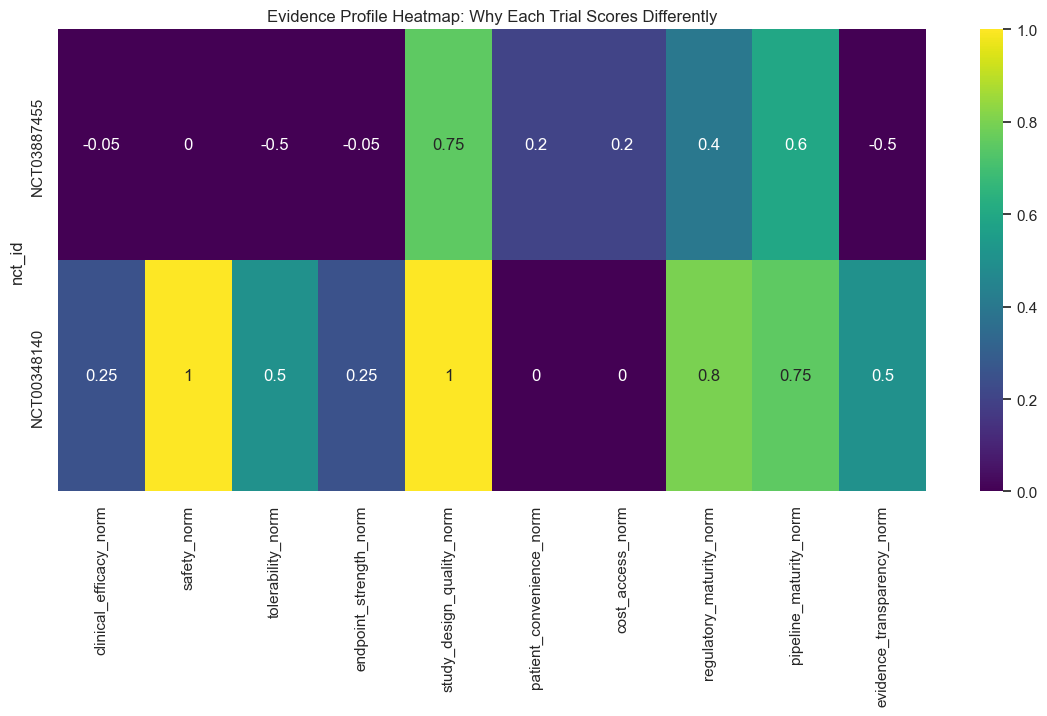

In [21]:
heatmap_cols = [
    'clinical_efficacy_norm',
    'safety_norm',
    'tolerability_norm',
    'endpoint_strength_norm',
    'study_design_quality_norm',
    'patient_convenience_norm',
    'cost_access_norm',
    'regulatory_maturity_norm',
    'pipeline_maturity_norm',
    'evidence_transparency_norm'
]

available_heatmap_cols = [c for c in heatmap_cols if c in scored_df.columns]

plt.figure(figsize=(14, 6))
sns.heatmap(
    scored_df.set_index('nct_id')[available_heatmap_cols],
    annot=True,
    cmap='viridis',
    vmin=0,
    vmax=1
)
plt.title('Evidence Profile Heatmap: Why Each Trial Scores Differently')
plt.show()



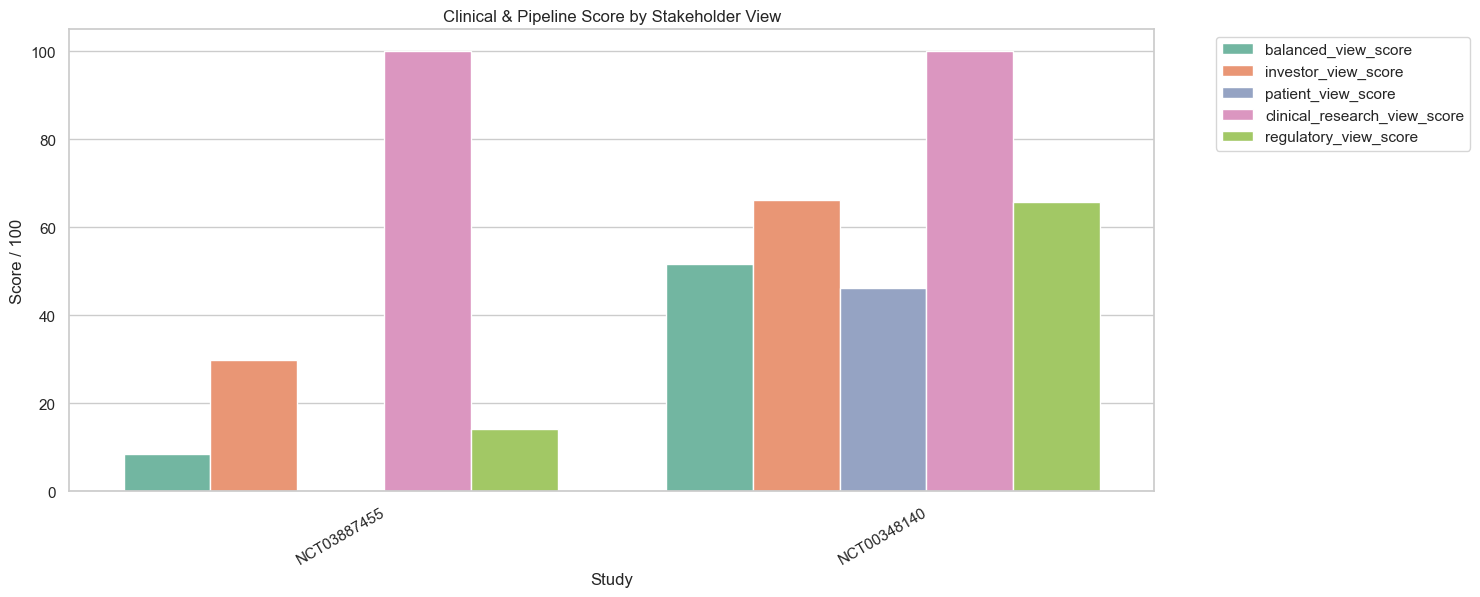

In [22]:
score_cols = [
    'balanced_view_score',
    'investor_view_score',
    'patient_view_score',
    'clinical_research_view_score',
    'regulatory_view_score'
]

plot_df = scored_df[['nct_id'] + score_cols].melt(
    id_vars='nct_id',
    var_name='view',
    value_name='score'
)

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x='nct_id', y='score', hue='view', palette='Set2')
plt.title('Clinical & Pipeline Score by Stakeholder View')
plt.ylabel('Score / 100')
plt.xlabel('Study')
plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



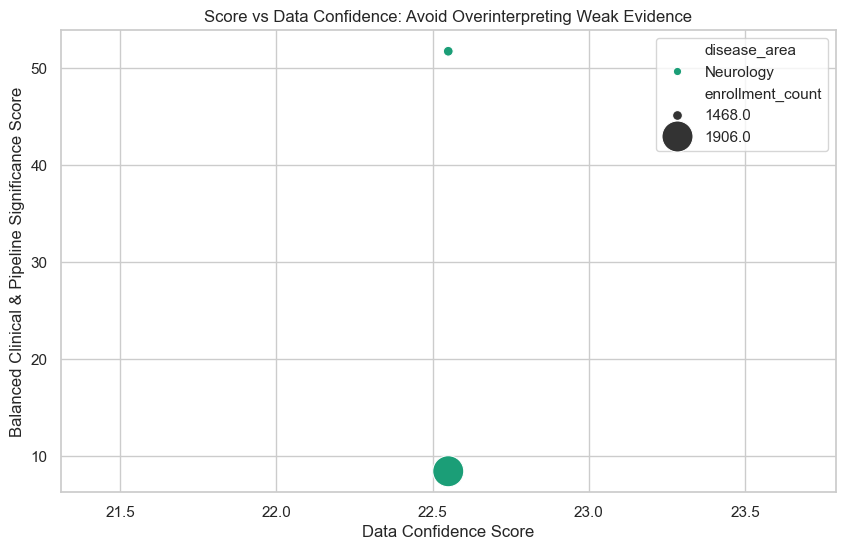

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scored_df,
    x='data_confidence_score',
    y='balanced_view_score',
    hue='disease_area',
    size='enrollment_count',
    sizes=(50, 500),
    palette='Dark2'
)
plt.title('Score vs Data Confidence: Avoid Overinterpreting Weak Evidence')
plt.xlabel('Data Confidence Score')
plt.ylabel('Balanced Clinical & Pipeline Significance Score')
plt.show()



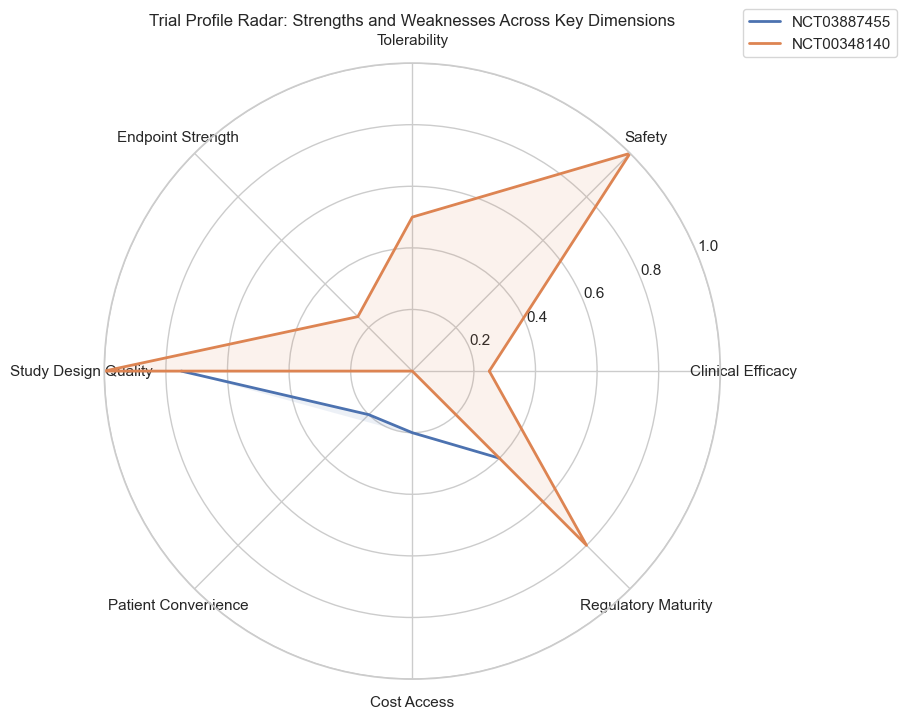

In [24]:
def plot_radar_for_studies(scored_df, nct_ids, factor_cols):
    labels = [c.replace('_norm', '').replace('_', ' ').title() for c in factor_cols]
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    for nct_id in nct_ids:
        row = scored_df[scored_df['nct_id'] == nct_id]
        if row.empty:
            continue

        values = row[factor_cols].iloc[0].fillna(0).tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=nct_id)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    plt.title('Trial Profile Radar: Strengths and Weaknesses Across Key Dimensions')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

radar_cols = available_heatmap_cols[:8]
plot_radar_for_studies(scored_df, scored_df['nct_id'].tolist(), radar_cols)



# Rank Stability Analysis

Dynamic weights are useful, but weights are subjective. To test whether conclusions are stable, we randomly perturb the weights and measure how often each trial ranks first.

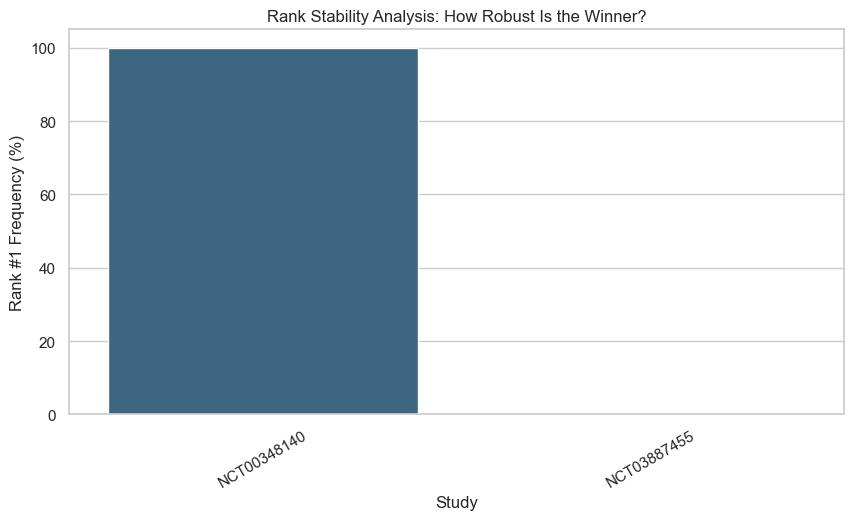

,nct_id,rank_1_count,rank_1_percentage
1,NCT00348140,1000,100.0
0,NCT03887455,0,0.0


In [25]:
# ── Rank Stability / Weight Sensitivity Analysis ─────────────────────────────
def randomize_weights_around_preset(base_weights, n_simulations=1000, noise_scale=0.25, seed=42):
    rng = np.random.default_rng(seed)
    dimensions = list(base_weights.keys())
    base = np.array([base_weights[d] for d in dimensions], dtype=float)
    base = base / base.sum()

    simulations = []

    for _ in range(n_simulations):
        noise = rng.lognormal(mean=0, sigma=noise_scale, size=len(base))
        sampled = base * noise
        sampled = sampled / sampled.sum()
        simulations.append(dict(zip(dimensions, sampled)))

    return simulations

def calculate_score_with_custom_weights(row, custom_weights):
    weighted_sum = 0
    used_weight = 0

    for dimension, weight in custom_weights.items():
        raw_col = DIMENSION_TO_RAW_COLUMN.get(dimension)
        if not raw_col:
            continue

        norm_col = raw_col.replace("_raw", "_norm")
        value = row.get(norm_col)

        if pd.notna(value):
            weighted_sum += float(value) * weight
            used_weight += weight

    if used_weight == 0:
        return np.nan

    score = weighted_sum / used_weight

    # Apply same penalties as main scoring if available
    if row.get("status_penalty_norm", 0) > 0:
        score -= 0.15

    if row.get("missing_endpoint_penalty_norm", 0) > 0:
        score -= 0.10

    return max(0, min(1, score)) * 100

def run_rank_stability_analysis(scored_df, preset_name="balanced_view", n_simulations=1000):
    base_weights = WEIGHT_PRESETS[preset_name]
    weight_sets = randomize_weights_around_preset(base_weights, n_simulations=n_simulations)

    winner_counts = {nct: 0 for nct in scored_df["nct_id"].tolist()}
    rank_records = []

    for i, weights in enumerate(weight_sets):
        temp = scored_df.copy()
        temp["simulated_score"] = temp.apply(lambda row: calculate_score_with_custom_weights(row, weights), axis=1)
        temp = temp.sort_values("simulated_score", ascending=False).reset_index(drop=True)

        winner = temp.iloc[0]["nct_id"]
        winner_counts[winner] += 1

        for rank_idx, row in temp.iterrows():
            rank_records.append({
                "simulation": i,
                "nct_id": row["nct_id"],
                "rank": rank_idx + 1,
                "simulated_score": row["simulated_score"]
            })

    stability_df = pd.DataFrame({
        "nct_id": list(winner_counts.keys()),
        "rank_1_count": list(winner_counts.values())
    })

    stability_df["rank_1_percentage"] = round(stability_df["rank_1_count"] / n_simulations * 100, 2)

    return stability_df.sort_values("rank_1_percentage", ascending=False), pd.DataFrame(rank_records)

rank_stability_df, rank_records_df = run_rank_stability_analysis(scored_df, "balanced_view", 1000)

plt.figure(figsize=(10, 5))
sns.barplot(data=rank_stability_df, x="nct_id", y="rank_1_percentage", hue="nct_id", palette="viridis", legend=False)
plt.title("Rank Stability Analysis: How Robust Is the Winner?")
plt.ylabel("Rank #1 Frequency (%)")
plt.xlabel("Study")
plt.xticks(rotation=30)
plt.show()

display(rank_stability_df)


# Evidence Waterfall Chart

The evidence waterfall explains score intent. It shows which factors increased the score and which penalties reduced it.

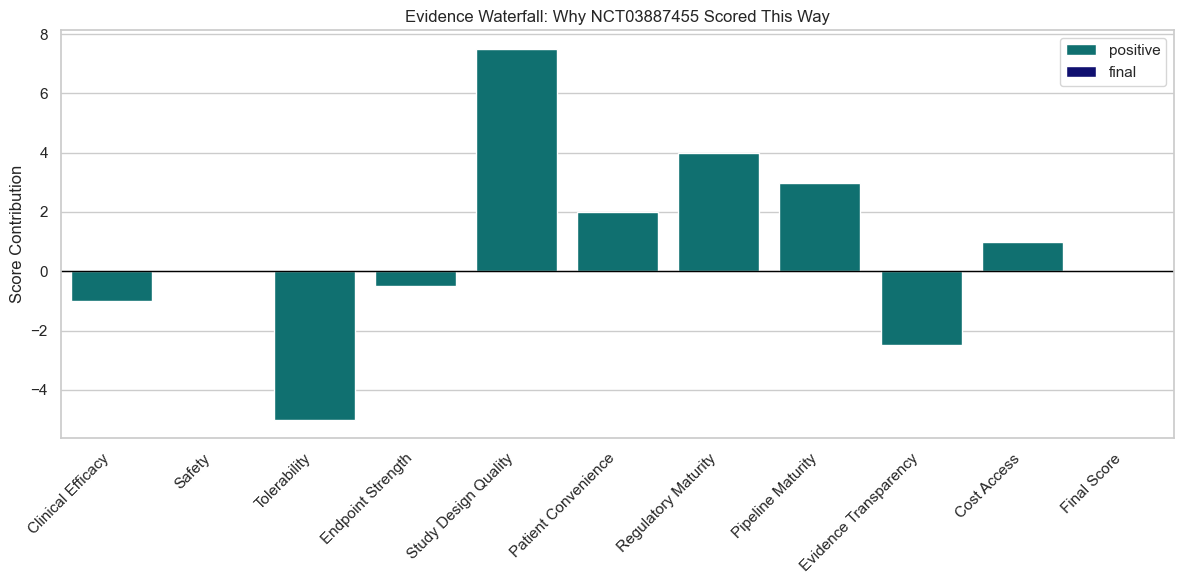

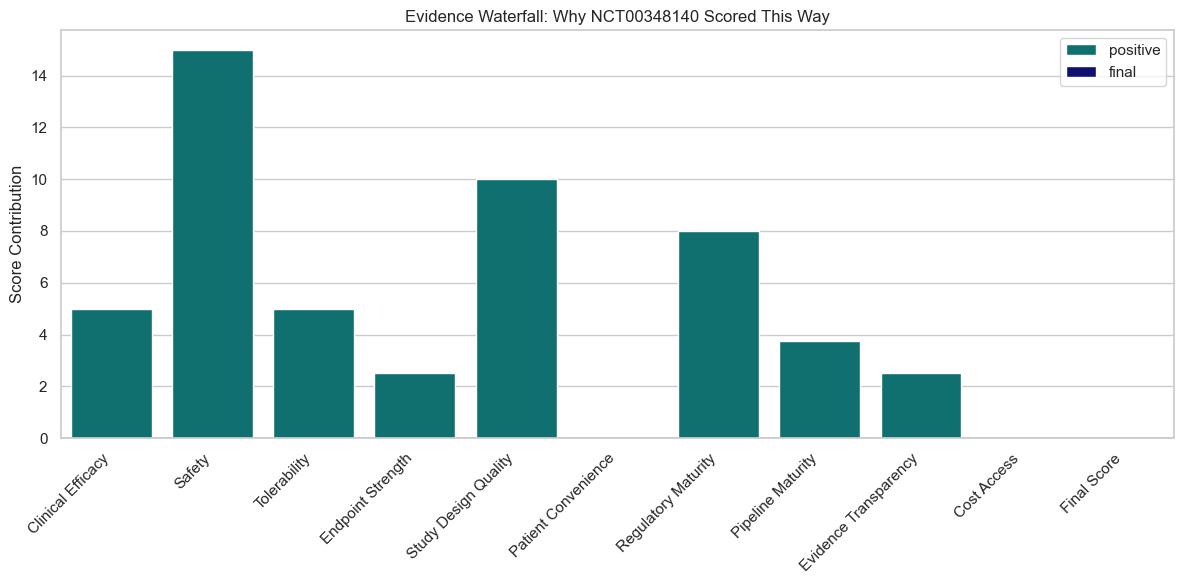

In [26]:
# ── Evidence Waterfall Analysis ─────────────────────────────────────────────
def build_evidence_waterfall_data(row, preset_name="balanced_view"):
    weights = normalize_weights(WEIGHT_PRESETS[preset_name])

    records = []
    cumulative = 0

    for dimension, weight in weights.items():
        raw_col = DIMENSION_TO_RAW_COLUMN.get(dimension)
        if not raw_col:
            continue

        norm_col = raw_col.replace("_raw", "_norm")
        value = row.get(norm_col)

        if pd.isna(value):
            continue

        contribution = float(value) * weight * 100
        cumulative += contribution

        records.append({
            "component": dimension.replace("_", " ").title(),
            "contribution": contribution,
            "cumulative": cumulative,
            "type": "positive"
        })

    penalties = []

    if row.get("status_penalty_norm", 0) > 0:
        penalties.append(("Negative Status Penalty", -15))

    if row.get("missing_endpoint_penalty_norm", 0) > 0:
        penalties.append(("Missing Endpoint Penalty", -10))

    for name, penalty in penalties:
        cumulative += penalty
        records.append({
            "component": name,
            "contribution": penalty,
            "cumulative": cumulative,
            "type": "penalty"
        })

    records.append({
        "component": "Final Score",
        "contribution": 0,
        "cumulative": max(0, min(100, cumulative)),
        "type": "final"
    })

    return pd.DataFrame(records)

def plot_evidence_waterfall(scored_df, nct_id, preset_name="balanced_view"):
    row = scored_df[scored_df["nct_id"] == nct_id].iloc[0]
    waterfall_df = build_evidence_waterfall_data(row, preset_name)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=waterfall_df, x="component", y="contribution", hue="type", dodge=False, palette={"positive": "teal", "penalty": "crimson", "final": "navy"})
    plt.axhline(0, color="black", linewidth=1)
    plt.title(f"Evidence Waterfall: Why {nct_id} Scored This Way")
    plt.ylabel("Score Contribution")
    plt.xlabel("")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="")
    plt.tight_layout()
    plt.show()

for nct_id in scored_df["nct_id"].tolist():
    plot_evidence_waterfall(scored_df, nct_id, "balanced_view")


# Missing Evidence Matrix

Shows what is missing or not parsed from source data.

,nct_id,Primary endpoint,Results section,Outcome results,Statistical analysis,Adverse events,Serious adverse events,Participant flow,Baseline characteristics,Publications,Comparator/design clarity,Masking/blinding
0,NCT03887455,1,0,0,0,0,0,0,0,0,0,1
1,NCT00348140,1,0,0,0,0,0,0,0,0,1,1


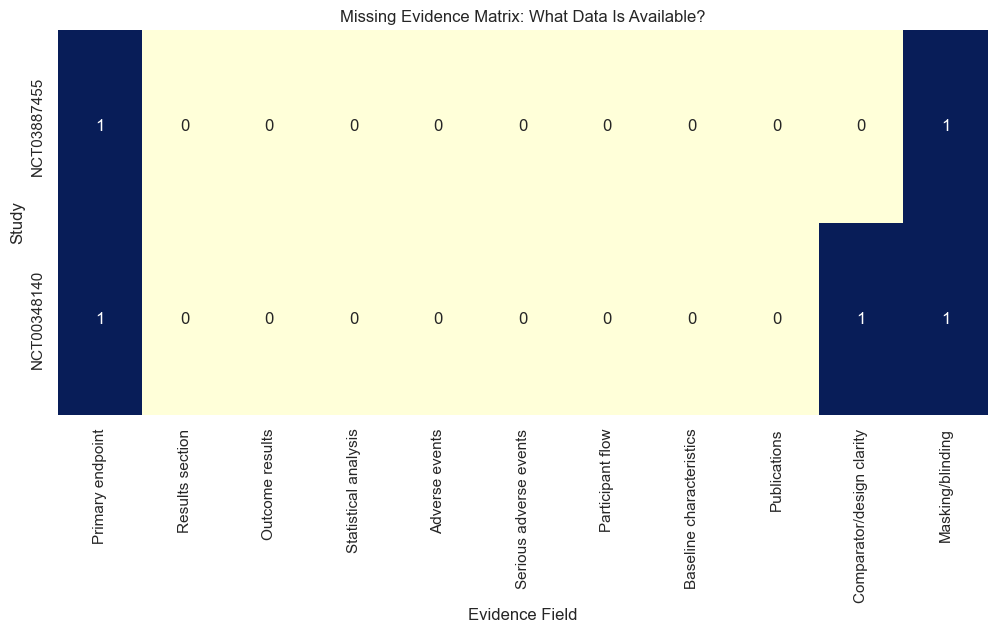

In [27]:
# ── Missing Evidence Matrix ─────────────────────────────────────────────
MISSING_EVIDENCE_CHECKS = {
    "Primary endpoint": "primary_endpoint_count",
    "Results section": "results_section_available",
    "Outcome results": "outcome_results_available",
    "Statistical analysis": "statistical_analysis_count",
    "Adverse events": "adverse_events_available",
    "Serious adverse events": "serious_adverse_event_count",
    "Participant flow": "participant_flow_available",
    "Baseline characteristics": "baseline_available",
    "Publications": "publication_count",
    "Comparator/design clarity": "has_control_signal",
    "Masking/blinding": "has_masking"
}

def build_missing_evidence_matrix(scored_df):
    rows = []

    for _, row in scored_df.iterrows():
        record = {"nct_id": row["nct_id"]}

        for label, field in MISSING_EVIDENCE_CHECKS.items():
            value = row.get(field)

            if field in ["statistical_analysis_count", "publication_count", "primary_endpoint_count"]:
                available = pd.notna(value) and float(value) > 0
            elif field in ["serious_adverse_event_count"]:
                available = pd.notna(value)
            else:
                available = bool(value)

            record[label] = 1 if available else 0

        rows.append(record)

    return pd.DataFrame(rows)

missing_matrix_df = build_missing_evidence_matrix(scored_df)
display(missing_matrix_df)

plt.figure(figsize=(12, 5))
sns.heatmap(
    missing_matrix_df.set_index("nct_id"),
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar=False
)
plt.title("Missing Evidence Matrix: What Data Is Available?")
plt.xlabel("Evidence Field")
plt.ylabel("Study")
plt.show()


# Estimand-Style Clinical Question Checker

This section asks: what clinical question is this trial actually trying to answer?

A strong trial record should clarify population, treatment, comparator, endpoint, summary measure, and handling of intercurrent events.

In [28]:
# ── Estimand-Style Clinical Question Checker Table ─────────────────────────
estimand_cols = [
    "nct_id",
    "estimand_population_available",
    "estimand_treatment_available",
    "estimand_comparator_available",
    "estimand_endpoint_available",
    "estimand_summary_measure_available",
    "estimand_intercurrent_events_available",
    "estimand_completeness_score"
]
display(scored_df[estimand_cols])


,nct_id,estimand_population_available,estimand_treatment_available,estimand_comparator_available,estimand_endpoint_available,estimand_summary_measure_available,estimand_intercurrent_events_available,estimand_completeness_score
0,NCT03887455,False,False,False,False,False,False,0.00
1,NCT00348140,False,False,True,False,False,False,16.67


# Clinical Reasoning Tree

This is a rule-based clinical reasoning tree for explanation of findings.

In [29]:
# ── Clinical Reasoning Tree ──────────────────────────────────────────────────
def generate_clinical_reasoning_tree(row):
    lines = []

    lines.append("Clinical Reasoning Tree")

    if row.get("has_results", 0):
        lines.append("Results posted: yes → efficacy/safety interpretation may be possible if result details are parsed.")
    else:
        lines.append("Results posted: no → efficacy cannot be judged from registry results.")

    if row.get("primary_endpoint_count", 0) > 0:
        lines.append("Primary endpoint available: yes → endpoint meaningfulness can be assessed.")
    else:
        lines.append("Primary endpoint available: no → endpoint interpretation is weak.")

    if row.get("endpoint_type") in ["Hard clinical endpoint", "Patient-reported / quality-of-life endpoint"]:
        lines.append(f"Endpoint type: {row.get('endpoint_type')} → stronger clinical meaning.")
    elif row.get("endpoint_type") in ["Surrogate / biomarker endpoint", "Intermediate oncology endpoint"]:
        lines.append(f"Endpoint type: {row.get('endpoint_type')} → useful but may require validation against clinical benefit.")
    else:
        lines.append(f"Endpoint type: {row.get('endpoint_type')} → clinical meaning may be limited or unclear.")

    if row.get("actual_adverse_event_data_available", 0):
        lines.append("Adverse-event data available: yes → safety interpretation can be attempted.")
    else:
        lines.append("Adverse-event data available: no → safety/tolerability confidence is limited.")

    if row.get("has_control_signal", 0):
        lines.append("Comparator/control signal: yes → causal interpretation is stronger.")
    else:
        lines.append("Comparator/control signal: not clearly available → causal interpretation is weaker.")

    if row.get("data_confidence_score", 0) < 60:
        lines.append("Data confidence: low/moderate → avoid strong conclusions.")
    else:
        lines.append("Data confidence: acceptable → interpretation is more supportable, but still not predictive.")

    return "\n".join(lines)

scored_df["clinical_reasoning_tree"] = scored_df.apply(generate_clinical_reasoning_tree, axis=1)

for _, row in scored_df.iterrows():
    print("\n" + "="*80)
    print(row["nct_id"])
    print(row["clinical_reasoning_tree"])



NCT03887455
Clinical Reasoning Tree
Results posted: no → efficacy cannot be judged from registry results.
Primary endpoint available: yes → endpoint meaningfulness can be assessed.
Endpoint type: Safety endpoint → clinical meaning may be limited or unclear.
Adverse-event data available: no → safety/tolerability confidence is limited.
Comparator/control signal: not clearly available → causal interpretation is weaker.
Data confidence: low/moderate → avoid strong conclusions.

NCT00348140
Clinical Reasoning Tree
Results posted: yes → efficacy/safety interpretation may be possible if result details are parsed.
Primary endpoint available: yes → endpoint meaningfulness can be assessed.
Endpoint type: Patient-reported / quality-of-life endpoint → stronger clinical meaning.
Adverse-event data available: yes → safety interpretation can be attempted.
Comparator/control signal: yes → causal interpretation is stronger.
Data confidence: low/moderate → avoid strong conclusions.


# Endpoint Meaningfulness Table

Categorizes primary efficacy endpoints based on Tiers 1-5 to assess clinical validity.

In [30]:
# ── Endpoint Meaningfulness Table ───────────────────────────────────────────
def build_endpoint_meaningfulness_table(scored_df):
    rows = []

    for _, row in scored_df.iterrows():
        endpoint_type = row.get("endpoint_type", "Endpoint not clearly available")

        if endpoint_type == "Hard clinical endpoint":
            tier = "Tier 1"
            explanation = "Direct clinical outcome such as survival, mortality, hospitalization, remission, relapse, or disability."
        elif endpoint_type == "Patient-reported / quality-of-life endpoint":
            tier = "Tier 2"
            explanation = "Patient-centered outcome that may capture real-world benefit."
        elif endpoint_type == "Intermediate oncology endpoint":
            tier = "Tier 3"
            explanation = "Useful intermediate endpoint, but may not fully represent long-term clinical benefit."
        elif endpoint_type == "Surrogate / biomarker endpoint":
            tier = "Tier 4"
            explanation = "Biological or surrogate measure that may need validation against clinical outcomes."
        elif endpoint_type == "Safety endpoint":
            tier = "Tier 5"
            explanation = "Important for safety, but not enough alone to prove efficacy."
        else:
            tier = "Unclear"
            explanation = "Endpoint meaning is not clearly available from parsed source data."

        rows.append({
            "nct_id": row.get("nct_id"),
            "endpoint_type": endpoint_type,
            "endpoint_tier": tier,
            "clinical_meaning": explanation
        })

    return pd.DataFrame(rows)

endpoint_meaningfulness_df = build_endpoint_meaningfulness_table(scored_df)
display(endpoint_meaningfulness_df)


,nct_id,endpoint_type,endpoint_tier,clinical_meaning
0,NCT03887455,Safety endpoint,Tier 5,"Important for safety, but not enough alone to prove efficacy."
1,NCT00348140,Patient-reported / quality-of-life endpoint,Tier 2,Patient-centered outcome that may capture real-world benefit.


In [31]:
def generate_strengths_risks(row):
    strengths = []
    risks = []
    missing = []

    if row.get('phase_numeric', 0) >= 3:
        strengths.append('Late-stage clinical development signal')
    elif row.get('phase_numeric', 0) <= 1:
        risks.append('Early-stage evidence only')

    if row.get('enrollment_count', 0) >= 200:
        strengths.append('Moderate-to-large enrollment')
    elif row.get('enrollment_count', 0) < 50:
        risks.append('Small enrollment size')

    if row.get('has_results', 0) == 1:
        strengths.append('Results are available in the source record')
    else:
        missing.append('No posted results found in ClinicalTrials.gov record')

    if row.get('publication_count', 0) > 0:
        strengths.append('Linked publication evidence available')
    else:
        missing.append('No linked publication found')

    if row.get('primary_endpoint_count', 0) > 0:
        strengths.append('Primary endpoint available')
    else:
        risks.append('Primary endpoint not clearly available')

    if row.get('is_randomized', 0) == 1:
        strengths.append('Randomized design signal')
    else:
        risks.append('Randomization not clearly identified')

    if row.get('has_masking', 0) == 1:
        strengths.append('Masking/blinding signal available')
    else:
        risks.append('Masking/blinding not clearly identified')

    if row.get('country_count', 0) > 1:
        strengths.append('Multi-country study signal')
    else:
        risks.append('Limited geographic diversity based on available locations')

    if row.get('is_negative_status', 0) == 1:
        risks.append('Terminated, withdrawn, or suspended status signal')

    return {
        'strengths': strengths,
        'risks': risks,
        'missing_data': missing
    }

flags = scored_df.apply(generate_strengths_risks, axis=1)
scored_df['strengths'] = flags.apply(lambda x: x['strengths'])
scored_df['risks'] = flags.apply(lambda x: x['risks'])
scored_df['missing_data'] = flags.apply(lambda x: x['missing_data'])

display(scored_df[['nct_id', 'strengths', 'risks', 'missing_data']])


,nct_id,strengths,risks,missing_data
0,NCT03887455,"[Late-stage clinical development signal, Moderate-to-large enrollment, Primary endpoint available, Randomized design signal, Masking/blinding signal availab...",[],"[No posted results found in ClinicalTrials.gov record, No linked publication found]"
1,NCT00348140,"[Late-stage clinical development signal, Moderate-to-large enrollment, Results are available in the source record, Primary endpoint available, Randomized de...",[],[No linked publication found]


In [32]:
def build_pipeline_summary(df):
    temp = df.copy()

    temp['enrollment'] = pd.to_numeric(temp['enrollment'], errors='coerce')
    temp['phase_numeric'] = temp['phase'].apply(phase_to_numeric)
    temp['status_norm'] = temp['status'].fillna('').str.lower()

    group_cols = ['category', 'sponsor', 'phase', 'status']

    pipeline = temp.groupby(group_cols).agg(
        number_of_studies=('nct_id', 'count'),
        average_enrollment=('enrollment', 'mean'),
        max_enrollment=('enrollment', 'max'),
        average_phase_numeric=('phase_numeric', 'mean'),
    ).reset_index()

    pipeline['completed_flag'] = pipeline['status'].str.lower().str.contains('completed', na=False)
    pipeline['active_flag'] = pipeline['status'].str.lower().str.contains('recruiting|active|not yet', na=False)
    pipeline['negative_status_flag'] = pipeline['status'].str.lower().str.contains('terminated|withdrawn|suspended', na=False)

    return pipeline.sort_values('number_of_studies', ascending=False)

pipeline_summary_df = build_pipeline_summary(df)
display(pipeline_summary_df.head(30))


,category,sponsor,phase,status,number_of_studies,average_enrollment,max_enrollment,average_phase_numeric,completed_flag,active_flag,negative_status_flag
1991,Oncology,National Cancer Institute (NCI),PHASE2,COMPLETED,31,43.516129,101,2.0,True,False,False
632,Autoimmune,Novo Nordisk A/S,PHASE3,COMPLETED,26,916.692308,9341,3.0,True,False,False
629,Autoimmune,Novo Nordisk A/S,PHASE1,COMPLETED,21,64.619048,384,1.0,True,False,False
1986,Oncology,National Cancer Institute (NCI),PHASE1,COMPLETED,20,32.750000,58,1.0,True,False,False
1858,Oncology,M.D. Anderson Cancer Center,PHASE2,COMPLETED,16,63.062500,197,2.0,True,False,False
263,Autoimmune,Eli Lilly and Company,PHASE3,COMPLETED,14,1131.714286,9901,3.0,True,False,False
1852,Oncology,M.D. Anderson Cancer Center,PHASE1,COMPLETED,12,25.416667,63,1.0,True,False,False
1677,Oncology,Hoffmann-La Roche,PHASE3,COMPLETED,11,782.272727,2185,3.0,True,False,False
92,Autoimmune,AstraZeneca,PHASE3,COMPLETED,9,2335.444444,17190,3.0,True,False,False
758,Autoimmune,Sanofi,PHASE4,COMPLETED,9,1064.888889,7376,4.0,True,False,False


## Competitive Benchmark: Why This Matters

Large clinical intelligence platforms focus on trial design, enrollment timelines, patient populations, endpoints, outcomes, geography, sites, investigators, and drug development pipelines.

MindReader’s opportunity is to create a more explainable decision layer:
- Start from public clinical trial data
- Extract comparable structured factors
- Normalize factors into a common scale
- Apply dynamic weights depending on user view
- Produce a transparent Clinical & Pipeline Significance Score
- Explain why a study or pipeline looks strong, weak, risky, or incomplete

This does not replace enterprise clinical databases. It demonstrates an approval-ready method for turning complex trial data into understandable biotech intelligence.

### Industry Context:
- **Reference platform**: Citeline
- **Reference website**: [Citeline](https://www.citeline.com/en/)
- **MindReader site**: [MindReader Biotech](https://www.mindreaderbio.tech/)

Do not copy Citeline’s product. Use it only as market context.


In [33]:
def generate_plain_english_interpretation(scored_df, selected_score_col='balanced_view_score'):
    if scored_df.empty:
        return 'No studies available for interpretation.'

    best = scored_df.sort_values(selected_score_col, ascending=False).iloc[0]
    weakest = scored_df.sort_values(selected_score_col, ascending=True).iloc[0]
    lowest_conf = scored_df.sort_values('data_confidence_score', ascending=True).iloc[0]

    lines = []

    lines.append('## So What It Means')
    lines.append('')
    lines.append(
        f"Based on the selected scoring view, **{best['nct_id']}** has the strongest Clinical & Pipeline Significance Score "
        f"({best[selected_score_col]}/100). This appears to be driven by factors such as endpoint strength, study maturity, design quality, "
        f"results/publication transparency, patient convenience, and pipeline context where available."
    )
    lines.append('')
    lines.append(
        f"**{weakest['nct_id']}** has the lowest score in this selected comparison ({weakest[selected_score_col]}/100). "
        f"This does not mean the therapy failed. It means the available structured data gives weaker evidence or more missing/risk signals under the current weighting method."
    )
    lines.append('')
    lines.append(
        f"The study with the lowest data confidence is **{lowest_conf['nct_id']}** ({lowest_conf['data_confidence_score']}/100). "
        f"This means its score should be interpreted carefully because some source fields are missing or incomplete."
    )
    lines.append('')
    lines.append('### Key Reminder')
    lines.append('')
    lines.append(
        'A low score in the comparison does not represent a lack of therapeutic potential or clinical failure. '
        'It indicates that under the active weighting preset (e.g., balanced, patient, or investor view), the study '
        'has fewer of the positive structural indicators (such as late-stage phase, high enrollment, posted results, or '
        'highly convenient modality like oral administration) or carries specific penalties (like negative overall status or missing endpoints).'
    )
    lines.append('')
    lines.append('### Transparent Score Breakdown')
    for idx, row in scored_df.iterrows():
        lines.append(f"- **{row['nct_id']} ({row['sponsor']})**:")
        lines.append(f"  - Clinical & Pipeline Significance Score ({selected_score_col}): **{row[selected_score_col]}/100**")
        lines.append(f"  - Data Confidence Score: **{row['data_confidence_score']}/100**")
        
        # Breakdown of contributing factors
        breakdown = row.get(f"{selected_score_col.replace('_score', '')}_breakdown", {})
        lines.append('  - Major Contributing Dimension Contributions:')
        for dim, details in breakdown.items():
            if details.get('weighted_contribution', 0) > 0.01:
                lines.append(f"    - {dim.replace('_', ' ').title()}: {round(details['weighted_contribution'] * 100, 1)} points (Normalized Value: {details['normalized_value']}, Weight: {details['weight']})")
        
        penalties = row.get(f"{selected_score_col.replace('_score', '')}_penalty", 0)
        reasons = row.get(f"{selected_score_col.replace('_score', '')}_penalty_reasons", [])
        if penalties > 0:
            lines.append(f"  - Applied Penalties: -{round(penalties, 1)} points due to: {', '.join(reasons)}")
            
    return '\n'.join(lines)

interpretation_md = generate_plain_english_interpretation(scored_df, 'balanced_view_score')
from IPython.display import Markdown
display(Markdown(interpretation_md))


## So What It Means

Based on the selected scoring view, **NCT00348140** has the strongest Clinical & Pipeline Significance Score (51.75/100). This appears to be driven by factors such as endpoint strength, study maturity, design quality, results/publication transparency, patient convenience, and pipeline context where available.

**NCT03887455** has the lowest score in this selected comparison (8.48/100). This does not mean the therapy failed. It means the available structured data gives weaker evidence or more missing/risk signals under the current weighting method.

The study with the lowest data confidence is **NCT03887455** (22.55/100). This means its score should be interpreted carefully because some source fields are missing or incomplete.

### Key Reminder

A low score in the comparison does not represent a lack of therapeutic potential or clinical failure. It indicates that under the active weighting preset (e.g., balanced, patient, or investor view), the study has fewer of the positive structural indicators (such as late-stage phase, high enrollment, posted results, or highly convenient modality like oral administration) or carries specific penalties (like negative overall status or missing endpoints).

### Transparent Score Breakdown
- **NCT03887455 (Eisai Inc.)**:
  - Clinical & Pipeline Significance Score (balanced_view_score): **8.48/100**
  - Data Confidence Score: **22.55/100**
  - Major Contributing Dimension Contributions:
    - Study Design Quality: 7.5 points (Normalized Value: 0.75, Weight: 0.1)
    - Patient Convenience: 2.0 points (Normalized Value: 0.2, Weight: 0.1)
    - Regulatory Maturity: 4.0 points (Normalized Value: 0.4, Weight: 0.1)
    - Pipeline Maturity: 3.0 points (Normalized Value: 0.5968, Weight: 0.05)
- **NCT00348140 (GlaxoSmithKline)**:
  - Clinical & Pipeline Significance Score (balanced_view_score): **51.75/100**
  - Data Confidence Score: **22.55/100**
  - Major Contributing Dimension Contributions:
    - Clinical Efficacy: 5.0 points (Normalized Value: 0.25, Weight: 0.2)
    - Safety: 15.0 points (Normalized Value: 1.0, Weight: 0.15)
    - Tolerability: 5.0 points (Normalized Value: 0.5, Weight: 0.1)
    - Endpoint Strength: 2.5 points (Normalized Value: 0.25, Weight: 0.1)
    - Study Design Quality: 10.0 points (Normalized Value: 1.0, Weight: 0.1)
    - Regulatory Maturity: 8.0 points (Normalized Value: 0.8, Weight: 0.1)
    - Pipeline Maturity: 3.8 points (Normalized Value: 0.75, Weight: 0.05)
    - Evidence Transparency: 2.5 points (Normalized Value: 0.5, Weight: 0.05)

In [34]:
# ── LLM initialisation ───────────────────────────────────────────────────────
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

api_key = os.getenv('OPENROUTER_API_KEY')
if not api_key:
    raise ValueError('OPENROUTER_API_KEY not found. Add it to your .env file.')

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model='openrouter/free',
    openai_api_key=api_key,
    openai_api_base='https://openrouter.ai/api/v1',
    temperature=0.2,
    max_tokens=3000,
    timeout=45,
    default_headers={
        'HTTP-Referer': 'https://mindreaderbio.tech',
        'X-Title': 'MindReader Biotech Intelligence',
    },
)
print('LLM ready:', llm.model_name)



LLM ready: openrouter/free


In [35]:
# ── 1. Dynamic Analysis Dimension Registry ───────────────────────────────────
ANALYSIS_DIMENSION_REGISTRY = {
    'trial_identity': {
        'display_name': 'Trial Identity',
        'purpose': 'Identify what is being tested, in whom, by whom, and at what stage.',
        'required_fields': ['nct_id', 'brief_title', 'conditions', 'intervention_names', 'lead_sponsor', 'phase', 'status'],
        'optional_fields': ['official_title', 'study_type', 'primary_purpose', 'enrollment_count'],
        'analysis_questions': [
            'What is the trial testing?',
            'What disease or condition is being studied?',
            'What intervention or therapy is being evaluated?',
            'Who is the sponsor?',
            'What stage of development does the trial appear to represent?',
        ],
        'forbidden_claims': [
            'Do not infer efficacy.',
            'Do not infer safety.',
            'Do not claim regulatory approval.',
        ],
    },
    'clinical_efficacy_interpretability': {
        'display_name': 'Clinical Efficacy Interpretability',
        'purpose': 'Assess whether available source data allows interpretation of therapeutic benefit.',
        'required_fields': ['primary_outcomes', 'secondary_outcomes', 'has_results'],
        'optional_fields': ['raw_results_available', 'endpoint_type', 'status', 'enrollment_count'],
        'analysis_questions': [
            'Are efficacy endpoints available?',
            'Are results posted?',
            'Can therapeutic benefit be interpreted from the available source data?',
            'Are endpoints clinically meaningful or only surrogate/intermediate?',
            'What evidence is missing before efficacy can be judged?',
        ],
        'forbidden_claims': [
            'Do not say the therapy works unless source results support it.',
            'Do not invent p-values, effect sizes, or response rates.',
            'Do not infer clinical success from phase alone.',
        ],
    },
    'endpoint_meaningfulness': {
        'display_name': 'Endpoint Meaningfulness',
        'purpose': 'Judge whether endpoints are hard clinical, patient-centered, surrogate, biomarker, safety-only, or unclear.',
        'required_fields': ['primary_outcomes', 'secondary_outcomes'],
        'optional_fields': ['endpoint_type', 'primary_purpose', 'conditions'],
        'analysis_questions': [
            'What are the primary endpoints?',
            'Are endpoints hard clinical outcomes, patient-reported outcomes, surrogate endpoints, biomarkers, safety endpoints, or unclear?',
            'Do the endpoints align with the disease context?',
            'Would a non-expert understand why these endpoints matter?',
        ],
        'forbidden_claims': [
            'Do not claim endpoint success unless results are available.',
            'Do not assume regulatory acceptance of an endpoint.',
        ],
    },
    'safety_and_tolerability': {
        'display_name': 'Safety and Tolerability',
        'purpose': 'Assess what safety and tolerability information is available or missing.',
        'required_fields': ['has_results', 'primary_outcomes', 'secondary_outcomes'],
        'optional_fields': ['raw_results_available'],
        'analysis_questions': [
            'Is safety directly measured?',
            'Are adverse events available in source data?',
            'Are serious adverse events available?',
            'Is tolerability measured through discontinuation, withdrawal, QoL, or patient-reported outcomes?',
            'What safety/tolerability evidence is missing?',
        ],
        'forbidden_claims': [
            'Do not say the therapy has no side effects unless adverse-event data proves it.',
            'Do not invent adverse events.',
            'Do not infer tolerability only from study completion.',
        ],
    },
    'patient_adoption_burden': {
        'display_name': 'Patient Adoption Burden',
        'purpose': 'Analyze how easy or difficult the therapy may be for patients to use.',
        'required_fields': ['intervention_names', 'intervention_types'],
        'optional_fields': ['eligibility_criteria', 'countries', 'facility_count', 'primary_outcomes', 'secondary_outcomes'],
        'analysis_questions': [
            'Does the therapy appear oral, injectable, infusion-based, device-based, procedural, behavioral, or unclear?',
            'Does source data suggest patient burden such as visits, monitoring, specialized sites, or complex administration?',
            'Is home use likely or not inferable?',
            'What convenience information is missing?',
        ],
        'forbidden_claims': [
            'Do not invent dosing frequency.',
            'Do not invent cost.',
            'Do not infer home use unless source data suggests it.',
        ],
    },
    'population_relevance': {
        'display_name': 'Population Relevance',
        'purpose': 'Assess whether the enrolled population is clear, broad, narrow, biomarker-selected, severe, refractory, pediatric, adult, or unclear.',
        'required_fields': ['conditions', 'minimum_age', 'maximum_age', 'sex', 'eligibility_criteria'],
        'optional_fields': ['enrollment_count', 'countries', 'facility_count'],
        'analysis_questions': [
            'Who is eligible for the trial?',
            'Is the patient population broad or narrow?',
            'Are there age, sex, severity, prior-treatment, or biomarker restrictions?',
            'How generalizable does the population appear based on available data?',
        ],
        'forbidden_claims': [
            'Do not infer real-world generalizability beyond source data.',
            'Do not invent demographic diversity.',
        ],
    },
    'study_design_quality': {
        'display_name': 'Study Design Quality',
        'purpose': 'Assess design robustness based on randomization, comparator, masking, arms, study type, enrollment, and duration.',
        'required_fields': ['study_type', 'allocation', 'intervention_model', 'masking', 'number_of_arms', 'enrollment_count'],
        'optional_fields': ['primary_purpose', 'start_date', 'completion_date', 'countries', 'facility_count'],
        'analysis_questions': [
            'Is the study interventional or observational?',
            'Is randomization available?',
            'Is masking/blinding available?',
            'Is there a comparator or control signal?',
            'Is enrollment size adequate for interpretation?',
            'What design limitations are visible?',
        ],
        'forbidden_claims': [
            'Do not call a study definitive unless source evidence supports it.',
            'Do not infer statistical power unless sample-size assumptions are available.',
        ],
    },
    'regulatory_readiness': {
        'display_name': 'Regulatory Readiness',
        'purpose': 'Assess whether the trial looks exploratory, supportive, pivotal-like, or insufficient based on available structured data.',
        'required_fields': ['phase', 'status', 'has_results', 'primary_outcomes', 'study_type', 'enrollment_count'],
        'optional_fields': ['completion_date', 'publication_count', 'sponsor_class'],
        'analysis_questions': [
            'Does the trial appear early exploratory, mid-stage, late-stage, post-marketing, or unclear?',
            'Are results available?',
            'Are endpoints and design strong enough to support regulatory interpretation?',
            'What regulatory evidence is missing?',
        ],
        'forbidden_claims': [
            'Do not claim FDA/EMA approval likelihood.',
            'Do not claim the study is pivotal unless explicitly supported.',
            'Do not infer regulatory success.',
        ],
    },
    'economic_and_access_relevance': {
        'display_name': 'Economic and Access Relevance',
        'purpose': 'Identify cost/access questions and available proxies, without inventing price.',
        'required_fields': ['intervention_names', 'intervention_types', 'facility_count', 'countries'],
        'optional_fields': ['eligibility_criteria'],
        'analysis_questions': [
            'What cost/access factors can be inferred as questions or proxies?',
            'Does the intervention suggest expensive delivery such as infusion, biologic, cell therapy, specialized procedure, or device?',
            'Does the trial setting suggest specialized access burden?',
            'What pricing/reimbursement evidence is missing?',
        ],
        'forbidden_claims': [
            'Do not invent drug price.',
            'Do not invent reimbursement status.',
            'Do not claim cost-effectiveness unless economic data is available.',
        ],
    },
    'evidence_transparency': {
        'display_name': 'Evidence Transparency',
        'purpose': 'Assess whether the study has enough visible evidence to support interpretation.',
        'required_fields': ['has_results', 'publication_count', 'primary_outcomes', 'secondary_outcomes', 'status'],
        'optional_fields': ['completion_date', 'raw_results_available', 'publications'],
        'analysis_questions': [
            'Are results posted?',
            'Are publications linked?',
            'Are endpoints available?',
            'Is the study completed but missing results?',
            'What evidence should be reviewed next?',
        ],
        'forbidden_claims': [
            'Do not treat missing data as negative efficacy.',
            'Do not overinterpret incomplete records.',
        ],
    },
    'red_team_risk_review': {
        'display_name': 'Red-Team Risk Review',
        'purpose': 'Identify what could be misleading if someone only looked at phase, title, sponsor, or score.',
        'required_fields': ['nct_id', 'brief_title', 'phase', 'status', 'has_results', 'primary_outcomes', 'enrollment_count'],
        'optional_fields': ['publication_count', 'countries', 'facility_count'],
        'analysis_questions': [
            'What could be misleading about this trial?',
            'What should a user not conclude from the available data?',
            'What is the biggest interpretation risk?',
            'What evidence would change the analysis?',
        ],
        'forbidden_claims': [
            'Do not provide investment advice.',
            'Do not make treatment recommendations.',
            'Do not predict clinical success.',
        ],
    },
}

print(f'Registered {len(ANALYSIS_DIMENSION_REGISTRY)} analysis dimensions.')


Registered 11 analysis dimensions.


In [36]:
# ── 2. Dimension Availability Checker ────────────────────────────────────────
import pandas as pd

def get_available_analysis_dimensions(trial_data, registry):
    available = []
    for key, config in registry.items():
        required_fields = config.get('required_fields', [])
        present_count = 0
        for field in required_fields:
            value = trial_data.get(field)
            if value is None:
                continue
            if isinstance(value, float) and pd.isna(value):
                continue
            if isinstance(value, str) and value.strip() == '':
                continue
            if isinstance(value, list) and len(value) == 0:
                continue
            present_count += 1
        coverage = present_count / max(len(required_fields), 1)
        if coverage >= 0.4:
            status = 'available'
        elif coverage > 0:
            status = 'partial'
        else:
            status = 'insufficient'
        available.append({
            'dimension': key,
            'display_name': config['display_name'],
            'coverage': round(coverage, 2),
            'status': status,
            'required_fields': required_fields,
            'present_required_fields': present_count,
            'total_required_fields': len(required_fields),
        })
    return pd.DataFrame(available).sort_values('coverage', ascending=False)

if parsed_studies:
    sample_avail = get_available_analysis_dimensions(parsed_studies[0], ANALYSIS_DIMENSION_REGISTRY)
    display(sample_avail[['display_name', 'coverage', 'status', 'present_required_fields', 'total_required_fields']])


,display_name,coverage,status,present_required_fields,total_required_fields
0,Trial Identity,1.0,available,7,7
1,Clinical Efficacy Interpretability,1.0,available,3,3
2,Endpoint Meaningfulness,1.0,available,2,2
3,Safety and Tolerability,1.0,available,3,3
4,Patient Adoption Burden,1.0,available,2,2
5,Population Relevance,1.0,available,5,5
6,Study Design Quality,1.0,available,6,6
7,Regulatory Readiness,1.0,available,6,6
8,Economic and Access Relevance,1.0,available,4,4
9,Evidence Transparency,1.0,available,5,5


In [37]:
# ── 3. Trial AI Context Builder ──────────────────────────────────────────────
def prepare_trial_ai_context(trial_data, scored_row=None, max_text_chars=1500):
    context = {
        'source_note': 'Use only this structured source data. If something is missing, say Not available in source data.',
        'trial_identity': {
            'nct_id': trial_data.get('nct_id'),
            'brief_title': trial_data.get('brief_title'),
            'official_title': trial_data.get('official_title'),
            'status': trial_data.get('status'),
            'phase': trial_data.get('phase'),
            'study_type': trial_data.get('study_type'),
            'lead_sponsor': trial_data.get('lead_sponsor'),
            'sponsor_class': trial_data.get('sponsor_class'),
        },
        'disease_and_intervention': {
            'conditions': trial_data.get('conditions'),
            'keywords': trial_data.get('keywords'),
            'intervention_names': trial_data.get('intervention_names'),
            'intervention_types': trial_data.get('intervention_types'),
        },
        'design': {
            'allocation': trial_data.get('allocation'),
            'intervention_model': trial_data.get('intervention_model'),
            'masking': trial_data.get('masking'),
            'primary_purpose': trial_data.get('primary_purpose'),
            'number_of_arms': trial_data.get('number_of_arms'),
            'enrollment_count': trial_data.get('enrollment_count'),
            'start_date': trial_data.get('start_date'),
            'primary_completion_date': trial_data.get('primary_completion_date'),
            'completion_date': trial_data.get('completion_date'),
        },
        'outcomes': {
            'primary_outcomes': trial_data.get('primary_outcomes'),
            'secondary_outcomes': trial_data.get('secondary_outcomes'),
            'other_outcomes': trial_data.get('other_outcomes'),
        },
        'eligibility': {
            'minimum_age': trial_data.get('minimum_age'),
            'maximum_age': trial_data.get('maximum_age'),
            'sex': trial_data.get('sex'),
            'healthy_volunteers': trial_data.get('healthy_volunteers'),
            'eligibility_criteria_excerpt': str(trial_data.get('eligibility_criteria', ''))[:max_text_chars],
        },
        'locations': {
            'countries': trial_data.get('countries'),
            'facility_count': trial_data.get('facility_count'),
        },
        'evidence': {
            'has_results': trial_data.get('has_results'),
            'raw_results_available': trial_data.get('raw_results_available'),
            'publication_count': trial_data.get('publication_count'),
            'publications': trial_data.get('publications'),
        },
    }
    if scored_row is not None:
        sr = scored_row
        context['scores'] = {
            'balanced_view_score': float(sr.get('balanced_view_score', 0)),
            'investor_view_score': float(sr.get('investor_view_score', 0)),
            'patient_view_score': float(sr.get('patient_view_score', 0)),
            'clinical_research_view_score': float(sr.get('clinical_research_view_score', 0)),
            'regulatory_view_score': float(sr.get('regulatory_view_score', 0)),
            'data_confidence_score': float(sr.get('data_confidence_score', 0)),
            'endpoint_type': sr.get('endpoint_type'),
            'disease_area': sr.get('disease_area'),
            'modality': sr.get('modality'),
        }
    return context


In [38]:
# ── 4. Strict AI Prompt Builder ──────────────────────────────────────────────
import json

OUTPUT_SCHEMA_TEMPLATE = '''
{{
  "dimension_key": "{dim_key}",
  "dimension_name": "{dim_name}",
  "nct_id": "{nct}",
  "summary": "2-5 sentence analysis grounded only in source data.",
  "positive_signals": ["specific positive signal from source data"],
  "risk_signals": ["specific risk, limitation, or uncertainty from source data"],
  "missing_evidence": ["specific missing data needed for stronger interpretation"],
  "interpretation_level": "strong | moderate | weak | insufficient",
  "confidence": "high | medium | low",
  "source_fields_used": ["field names from the provided source data"],
  "do_not_conclude": ["things users should not conclude from this source data"]
}}
'''

def build_dimension_ai_prompt(trial_context, dimension_key, dimension_config):
    nct = trial_context['trial_identity'].get('nct_id', 'UNKNOWN')
    schema = OUTPUT_SCHEMA_TEMPLATE.format(
        dim_key=dimension_key,
        dim_name=dimension_config['display_name'],
        nct=nct,
    )
    parts = [
        'You are a clinical trial intelligence analyst for MindReader Biotech.',
        '',
        f'Analyze exactly one dimension: {dimension_config["display_name"]}',
        '',
        f'Purpose: {dimension_config["purpose"]}',
        '',
        'Use only the structured source data provided below.',
        'Do not use outside knowledge.',
        'Do not invent missing results, side effects, efficacy, safety, cost, market size, or regulatory claims.',
        'If a required fact is not available, write exactly: "Not available in source data."',
        '',
        'Analysis questions:',
        json.dumps(dimension_config.get('analysis_questions', []), indent=2),
        '',
        'Forbidden claims:',
        json.dumps(dimension_config.get('forbidden_claims', []), indent=2),
        '',
        'Source data:',
        json.dumps(trial_context, indent=2, default=str),
        '',
        'Return strict JSON only. No markdown, no explanation outside the JSON.',
        '',
        'Required output schema:',
        schema,
    ]
    return '\n'.join(parts)


In [39]:
def repair_ai_output(output, dimension_key, dimension_config, nct_id):
    defaults = {
        "dimension_key": dimension_key,
        "dimension_name": dimension_config["display_name"],
        "nct_id": nct_id,
        "summary": "Not available in source data.",
        "positive_signals": [],
        "risk_signals": [],
        "missing_evidence": [],
        "interpretation_level": "insufficient",
        "confidence": "low",
        "source_fields_used": [],
        "do_not_conclude": []
    }

    if not isinstance(output, dict):
        return defaults

    repaired = {**defaults, **output}

    level = str(repaired.get("interpretation_level", "")).lower().strip()
    level_map = {
        "high": "strong",
        "medium": "moderate",
        "low": "weak",
        "none": "insufficient",
        "not available": "insufficient"
    }

    repaired["interpretation_level"] = level_map.get(level, level)

    if repaired["interpretation_level"] not in ["strong", "moderate", "weak", "insufficient"]:
        repaired["interpretation_level"] = "insufficient"

    if str(repaired.get("confidence", "")).lower() not in ["high", "medium", "low"]:
        repaired["confidence"] = "low"

    for key in ["positive_signals", "risk_signals", "missing_evidence", "source_fields_used", "do_not_conclude"]:
        if repaired.get(key) is None:
            repaired[key] = []
        elif not isinstance(repaired.get(key), list):
            repaired[key] = [str(repaired[key])]

    return repaired

# ── 5. LLM Dimension Analysis Wrapper ────────────────────────────────────────
def run_ai_dimension_analysis(llm, trial_context, dimension_key, dimension_config):
    prompt = build_dimension_ai_prompt(trial_context, dimension_key, dimension_config)
    try:
        response = llm.invoke(prompt)
        text = response.content if hasattr(response, 'content') else str(response)
        text = text.strip()
        if text.startswith('```json'):
            text = text[7:]
        if text.startswith('```'):
            text = text[3:]
        if text.endswith('```'):
            text = text[:-3]
        text = text.strip()
        return json.loads(text)
    except Exception as e:
        nct = trial_context['trial_identity'].get('nct_id', 'UNKNOWN')
        return {
            'dimension_key': dimension_key,
            'dimension_name': dimension_config['display_name'],
            'nct_id': nct,
            'summary': f'AI analysis failed: {str(e)[:200]}',
            'positive_signals': [],
            'risk_signals': [str(e)[:300]],
            'missing_evidence': [],
            'interpretation_level': 'insufficient',
            'confidence': 'low',
            'source_fields_used': [],
            'do_not_conclude': ['Do not use this failed AI output for interpretation.'],
        }



In [40]:
# ── 6. Run AI Analysis One Dimension at a Time ───────────────────────────────
def run_full_dynamic_ai_analysis_for_trial(llm, trial_data, scored_row=None, registry=ANALYSIS_DIMENSION_REGISTRY):
    trial_context = prepare_trial_ai_context(trial_data, scored_row)
    availability_df = get_available_analysis_dimensions(trial_data, registry)
    outputs = []
    for _, dim_row in availability_df.iterrows():
        dimension_key = dim_row['dimension']
        dimension_config = registry[dimension_key]
        print(f"  → {dim_row['display_name']} (coverage={dim_row['coverage']}, status={dim_row['status']})")
        result = run_ai_dimension_analysis(
            llm=llm,
            trial_context=trial_context,
            dimension_key=dimension_key,
            dimension_config=dimension_config,
        )
        result['dimension_coverage'] = dim_row['coverage']
        result['dimension_availability_status'] = dim_row['status']
        outputs.append(result)
    return {
        'nct_id': trial_data.get('nct_id'),
        'availability': availability_df.to_dict(orient='records'),
        'dimension_outputs': outputs,
    }


all_ai_trial_outputs = []
for study in parsed_studies:
    nct_id = study.get('nct_id')
    scored_match = scored_df[scored_df['nct_id'] == nct_id]
    scored_row = scored_match.iloc[0] if not scored_match.empty else None
    print(f'\nRunning dynamic AI analysis for {nct_id}...')
    output = run_full_dynamic_ai_analysis_for_trial(llm=llm, trial_data=study, scored_row=scored_row)
    all_ai_trial_outputs.append(output)

total_dims = sum(len(t['dimension_outputs']) for t in all_ai_trial_outputs)
print(f'\nCompleted: {len(all_ai_trial_outputs)} trials, {total_dims} dimension outputs.')



Running dynamic AI analysis for NCT03887455...
  → Trial Identity (coverage=1.0, status=available)
  → Clinical Efficacy Interpretability (coverage=1.0, status=available)
  → Endpoint Meaningfulness (coverage=1.0, status=available)
  → Safety and Tolerability (coverage=1.0, status=available)
  → Patient Adoption Burden (coverage=1.0, status=available)
  → Population Relevance (coverage=1.0, status=available)
  → Study Design Quality (coverage=1.0, status=available)
  → Regulatory Readiness (coverage=1.0, status=available)
  → Economic and Access Relevance (coverage=1.0, status=available)
  → Evidence Transparency (coverage=1.0, status=available)
  → Red-Team Risk Review (coverage=1.0, status=available)

Running dynamic AI analysis for NCT00348140...
  → Trial Identity (coverage=1.0, status=available)
  → Clinical Efficacy Interpretability (coverage=1.0, status=available)
  → Endpoint Meaningfulness (coverage=1.0, status=available)
  → Safety and Tolerability (coverage=1.0, status=avai

In [41]:
# ── 7. Flatten AI Outputs to DataFrame ───────────────────────────────────────
def flatten_ai_outputs(all_ai_trial_outputs):
    rows = []
    for trial_output in all_ai_trial_outputs:
        for item in trial_output['dimension_outputs']:
            rows.append({
                'nct_id': item.get('nct_id'),
                'dimension_key': item.get('dimension_key'),
                'dimension_name': item.get('dimension_name'),
                'summary': item.get('summary'),
                'positive_signals': '; '.join(item.get('positive_signals') or []),
                'risk_signals': '; '.join(item.get('risk_signals') or []),
                'missing_evidence': '; '.join(item.get('missing_evidence') or []),
                'interpretation_level': item.get('interpretation_level'),
                'confidence': item.get('confidence'),
                'dimension_coverage': item.get('dimension_coverage'),
                'availability_status': item.get('dimension_availability_status'),
                'source_fields_used': '; '.join(item.get('source_fields_used') or []),
                'do_not_conclude': '; '.join(item.get('do_not_conclude') or []),
            })
    return pd.DataFrame(rows)


ai_analysis_df = flatten_ai_outputs(all_ai_trial_outputs)
display(ai_analysis_df[['nct_id', 'dimension_name', 'interpretation_level', 'confidence', 'summary']].head(20))


,nct_id,dimension_name,interpretation_level,confidence,summary
0,NCT03887455,Trial Identity,insufficient,medium,"The trial is a Phase 3, placebo-controlled, double‑blind, randomized, quadruple‑masked interventional study evaluating lecanemab (IV and SC) versus placebo ..."
1,NCT03887455,Clinical Efficacy Interpretability,insufficient,low,"The trial defines multiple efficacy endpoints, including change from baseline in CDR-SB and several cognitive scales, but no results have been posted or mad..."
2,NCT03887455,Endpoint Meaningfulness,weak,low,"The study’s primary endpoints include changes in the Clinical Dementia Rating–Sum of Boxes (CDR‑SB) at 18 months and over the extension period, as well as s..."
3,NCT03887455,Safety and Tolerability,insufficient,low,"AI analysis failed: Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-min. ', 'code': 429, 'metadata': {'headers': {'X-RateLimit..."
4,NCT03887455,Patient Adoption Burden,weak,low,"The intervention includes both intravenous (IV) and subcutaneous (SC) administration of Lecanemab, indicating an injectable modality. The source data does n..."
5,NCT03887455,Population Relevance,moderate,medium,"The trial enrolls adults aged 50 to 90 years of any sex with early Alzheimer's disease, defined as mild cognitive impairment due to AD or mild AD dementia. ..."
6,NCT03887455,Study Design Quality,moderate,medium,"The trial is an interventional, phase 3, randomized, quadruple‑masked, parallel‑group study with a placebo comparator and nine treatment arms enrolling 1,90..."
7,NCT03887455,Regulatory Readiness,weak,medium,"The trial is a Phase 3, randomized, quadruple‑masked, placebo‑controlled study with a large enrollment (1906) and a primary efficacy endpoint (CDR‑SB change..."
8,NCT03887455,Economic and Access Relevance,weak,medium,"The trial evaluates lecanemab, a biologic antibody administered intravenously (IV) and subcutaneously (SC), suggesting a potentially high-cost, specialized ..."
9,NCT03887455,Evidence Transparency,insufficient,low,"The trial registration lists detailed primary and secondary endpoints, but the evidence section indicates no results have been posted, no raw results are av..."


In [42]:
# ── 8. Trial Intelligence Cards ──────────────────────────────────────────────
from IPython.display import display, Markdown

def generate_trial_intelligence_card(nct_id, ai_analysis_df, scored_df):
    trial_ai = ai_analysis_df[ai_analysis_df['nct_id'] == nct_id]
    score_row = scored_df[scored_df['nct_id'] == nct_id]
    score_text = ''
    if not score_row.empty:
        r = score_row.iloc[0]
        bal  = r.get('balanced_view_score', 'NA')
        inv  = r.get('investor_view_score', 'NA')
        pat  = r.get('patient_view_score', 'NA')
        clin = r.get('clinical_research_view_score', 'NA')
        reg  = r.get('regulatory_view_score', 'NA')
        conf = r.get('data_confidence_score', 'NA')
        score_text = (
            '\n### Clinical & Pipeline Significance Scores\n\n'
            '| View | Score |\n|---|---|\n'
            f'| Balanced | {bal}/100 |\n'
            f'| Investor | {inv}/100 |\n'
            f'| Patient | {pat}/100 |\n'
            f'| Clinical Research | {clin}/100 |\n'
            f'| Regulatory | {reg}/100 |\n'
            f'| Data Confidence | {conf}/100 |\n'
        )
    lines = [f'# Trial Intelligence Card: {nct_id}', '', score_text, '', '## Dimension-Level AI Analysis', '']
    for _, row in trial_ai.iterrows():
        lines += [
            f"### {row['dimension_name']}", '',
            f"**Summary:** {row['summary']}", '',
            f"**Positive signals:** {row['positive_signals'] or 'Not available in source data.'}", '',
            f"**Risk signals:** {row['risk_signals'] or 'Not available in source data.'}", '',
            f"**Missing evidence:** {row['missing_evidence'] or 'Not available in source data.'}", '',
            f"**Confidence:** {row['confidence']} | **Interpretation:** {row['interpretation_level']}", '',
            f"**Do not conclude:** {row['do_not_conclude'] or 'No extra restriction noted.'}", '',
        ]
    return '\n'.join(lines)


trial_cards = {}
for nct_id in scored_df['nct_id'].tolist():
    card = generate_trial_intelligence_card(nct_id, ai_analysis_df, scored_df)
    trial_cards[nct_id] = card
    display(Markdown(card))


# Trial Intelligence Card: NCT03887455


### Clinical & Pipeline Significance Scores

| View | Score |
|---|---|
| Balanced | 8.48/100 |
| Investor | 29.85/100 |
| Patient | 0.0/100 |
| Clinical Research | 100/100 |
| Regulatory | 14.25/100 |
| Data Confidence | 22.55/100 |


## Dimension-Level AI Analysis

### Trial Identity

**Summary:** The trial is a Phase 3, placebo-controlled, double‑blind, randomized, quadruple‑masked interventional study evaluating lecanemab (IV and SC) versus placebo in participants with early Alzheimer's disease, including mild cognitive impairment due to AD and mild AD dementia. It is sponsored by Eisai Inc. and is currently active but not recruiting, with an enrollment target of 1,906 participants across 247 sites in multiple countries. The study includes an 18‑month core phase and an open‑label extension up to approximately 66 months.

**Positive signals:** Phase 3 status indicates advanced development; Large planned enrollment (1,906) across many international sites

**Risk signals:** Trial status is ACTIVE_NOT_RECRUITING, suggesting enrollment is complete and no new participants will be added; Primary completion and overall completion dates are projected for 2029, indicating long timelines before results are available; No results or publications are currently available

**Missing evidence:** Actual safety and efficacy results from the core and extension phases; Interim data or analysis of primary and secondary endpoints; Details on dosing regimens and any subgroup analyses

**Confidence:** medium | **Interpretation:** insufficient

**Do not conclude:** Efficacy of lecanemab in early Alzheimer's disease; Safety profile of lecanemab; Regulatory approval status; Commercial availability or market potential

### Clinical Efficacy Interpretability

**Summary:** The trial defines multiple efficacy endpoints, including change from baseline in CDR-SB and several cognitive scales, but no results have been posted or made available. Without posted results, therapeutic benefit cannot be interpreted from the source data. The primary efficacy endpoint (CDR-SB change at 18 months) is clinically meaningful, yet its outcome is missing.

**Positive signals:** Efficacy endpoints (e.g., CDR-SB, ADAS-cog14, ADCOMS) are specified and are clinically relevant measures for early Alzheimer's disease.

**Risk signals:** No efficacy results are available (has_results: false, raw_results_available: false).; The primary completion date is in the future (2029), indicating data are not yet generated.

**Missing evidence:** Actual outcome data for primary and secondary efficacy endpoints.; Statistical analyses (p-values, effect sizes, confidence intervals) for the efficacy measures.; Safety results are defined but not reported.

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** That lecanemab demonstrates clinical benefit.; Any efficacy magnitude or statistical significance.; Regulatory approval status based on efficacy.

### Endpoint Meaningfulness

**Summary:** The study’s primary endpoints include changes in the Clinical Dementia Rating–Sum of Boxes (CDR‑SB) at 18 months and over the extension period, as well as safety measures such as the number of participants reporting treatment‑emergent adverse events (TEAEs) and exposure duration. CDR‑SB is a clinician‑rated functional measure, not a hard clinical event, and TEAEs are safety‑only endpoints. These endpoints are relevant to early Alzheimer’s disease but are not patient‑reported or biomarker‑based, and the study does not report any hard clinical outcomes such as mortality or institutionalization. A non‑expert may recognize that CDR‑SB reflects disease progression, but may not appreciate its clinical significance without additional context.

**Positive signals:** Use of CDR‑SB, a validated clinical rating scale for Alzheimer’s disease progression; Inclusion of safety endpoints (TEAEs) to assess tolerability

**Risk signals:** Endpoints are not hard clinical outcomes (e.g., death, hospitalization); No patient‑reported outcome measures are included; No biomarker or surrogate endpoints are primary; Results for these endpoints are not available in the source data

**Missing evidence:** Outcome results (effect sizes, statistical significance); Patient‑reported outcome data; Information on whether CDR‑SB changes translate to meaningful daily functioning improvements; Long‑term safety data beyond the extension period

**Confidence:** low | **Interpretation:** weak

**Do not conclude:** Endpoint success or efficacy; Regulatory approval likelihood; Clinical benefit magnitude; Patient‑centered benefit without additional data

### Safety and Tolerability

**Summary:** AI analysis failed: Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-min. ', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '16', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset'

**Positive signals:** Not available in source data.

**Risk signals:** Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-min. ', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '16', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset': '1782325320000'}, 'provider_name': None, 'previous_errors': [{'code': 429, 'message': 'Rate limit 

**Missing evidence:** Not available in source data.

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** Do not use this failed AI output for interpretation.

### Patient Adoption Burden

**Summary:** The intervention includes both intravenous (IV) and subcutaneous (SC) administration of Lecanemab, indicating an injectable modality. The source data does not describe the frequency of dosing, the setting of administration, or monitoring requirements, so it is unclear whether patients would need frequent clinic visits or specialized sites. Home use cannot be inferred from the available information. Key convenience details such as dosing schedule, self‑administration feasibility, and monitoring burden are missing.

**Positive signals:** Intervention includes subcutaneous (SC) administration, which may allow for self‑injection at home if supported

**Risk signals:** No information on dosing frequency or monitoring requirements; unclear if clinic visits are required

**Missing evidence:** Dosing frequency and schedule; Home administration feasibility; Monitoring and visit requirements

**Confidence:** low | **Interpretation:** weak

**Do not conclude:** Whether patients can self‑administer Lecanemab at home; The exact burden of clinic visits or monitoring; The overall convenience of the therapy

### Population Relevance

**Summary:** The trial enrolls adults aged 50 to 90 years of any sex with early Alzheimer's disease, defined as mild cognitive impairment due to AD or mild AD dementia. Eligibility requires a positive amyloid biomarker, specific Clinical Dementia Rating scores (global 0.5‑1.0, memory box ≥0.5), MMSE ≥22, and objective memory impairment. This creates a relatively narrow, biomarker‑selected population focused on early disease rather than the broader AD spectrum.

**Positive signals:** Clear age range (50‑90 years) and inclusion of both sexes; Explicit requirement for amyloid positivity and defined CDR/MMSE thresholds

**Risk signals:** Population limited to early AD (MCI or mild dementia) with specific CDR and biomarker criteria, reducing breadth; No information on other exclusion criteria (e.g., comorbidities, prior treatments) that could further narrow eligibility

**Missing evidence:** Full list of exclusion criteria and any prior‑treatment restrictions; Detailed demographic breakdown (e.g., race/ethnicity) to assess diversity

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** Generalizability to all Alzheimer's patients beyond early disease; Efficacy or safety outcomes for the described population; Real‑world applicability across unreported demographic groups

### Study Design Quality

**Summary:** The trial is an interventional, phase 3, randomized, quadruple‑masked, parallel‑group study with a placebo comparator and nine treatment arms enrolling 1,906 participants across multiple countries. The primary purpose is treatment, with an 18‑month core period and an extended follow‑up up to 66 months. While the design incorporates strong methodological elements, no results are available and key details such as allocation ratios or power calculations are missing.

**Positive signals:** Randomized allocation (allocation = RANDOMIZED); Quadruple masking (masking = QUADRUPLE); Placebo comparator included (intervention_names includes Placebo); Large enrollment (enrollment_count = 1906); Multi‑regional site coverage (facility_count = 247 in 14 countries)

**Risk signals:** Nine arms may dilute sample size per arm and complicate interpretation; Primary completion date is 2029, and no results are posted (has_results = false); Active not recruiting status limits current enrollment verification

**Missing evidence:** Statistical power or sample‑size justification; Allocation ratios and detailed randomization scheme; Specific dosing regimens for each arm; Interim safety or efficacy data

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** Efficacy or safety outcomes of lecanemab; Statistical significance or power of the study; Final results or regulatory approval status

### Regulatory Readiness

**Summary:** The trial is a Phase 3, randomized, quadruple‑masked, placebo‑controlled study with a large enrollment (1906) and a primary efficacy endpoint (CDR‑SB change at 18 months) that aligns with regulatory expectations for Alzheimer’s disease. However, no results are available and the primary completion date is projected for 2029, leaving the regulatory relevance of the data unassessed at this time.

**Positive signals:** Phase 3 designation and robust design (randomized, parallel, quadruple masking) typical of pivotal trials; Large sample size (1906 participants) and global site footprint (247 facilities across 14 countries); Clinically meaningful primary endpoint (CDR‑SB change) and comprehensive safety endpoints

**Risk signals:** Results are not yet available (has_results: false); Primary completion date is far in the future (2029), creating uncertainty about data maturity; Multiple extension phase primary endpoints may dilute focus on the core pivotal analysis

**Missing evidence:** Actual efficacy and safety results for the primary and secondary endpoints; Statistical analysis plan details (e.g., alpha control, multiplicity adjustments); Regulatory interactions or pre‑submission meetings documented

**Confidence:** medium | **Interpretation:** weak

**Do not conclude:** The trial will receive FDA or EMA approval; The study is definitively pivotal without seeing results; Efficacy or safety conclusions can be drawn from the current data

### Economic and Access Relevance

**Summary:** The trial evaluates lecanemab, a biologic antibody administered intravenously (IV) and subcutaneously (SC), suggesting a potentially high-cost, specialized delivery modality. The study spans 14 countries and 247 sites, indicating a broad but possibly resource‑intensive enrollment infrastructure. No pricing, reimbursement, or health‑economic outcomes are reported, leaving the economic impact and patient access implications undefined.

**Positive signals:** Use of IV and SC formulations signals a biologic therapy that typically requires specialized administration infrastructure, which can be a proxy for higher cost.

**Risk signals:** Absence of any pricing, reimbursement, or cost‑effectiveness data limits assessment of affordability and payer uptake.; The multinational site network may imply logistical complexity that could affect patient access, but no data on site capacity or travel burden are provided.

**Missing evidence:** Drug acquisition price or cost per dose.; Reimbursement status or payer coverage information in the trial regions.; Health‑economic analyses (e.g., cost‑utility, budget impact).; Data on administration setting (e.g., infusion center vs. home) and associated resource use.

**Confidence:** medium | **Interpretation:** weak

**Do not conclude:** Exact drug price or cost per patient.; Reimbursement or coverage decisions in any market.; Cost‑effectiveness or value‑based conclusions.; That the therapy will be affordable or unaffordable for patients.

### Evidence Transparency

**Summary:** The trial registration lists detailed primary and secondary endpoints, but the evidence section indicates no results have been posted, no raw results are available, and no publications are linked. The study is still active (completion date 2029), so outcome data are not yet accessible. Consequently, the available evidence is limited to the protocol description.

**Positive signals:** Comprehensive list of primary and secondary endpoints is provided in the registration.

**Risk signals:** No results posted or linked publications; evidence section reports has_results = false and publication_count = 0.

**Missing evidence:** Posted results for primary and secondary outcomes; Peer‑reviewed publications reporting trial findings; Raw data or summary tables to substantiate endpoint measurements

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** Efficacy or safety of lecanemab based on this trial; Comparative advantage over other therapies; Regulatory approval status

### Red-Team Risk Review

**Summary:** The trial is a Phase 3, randomized, quadruple‑masked, placebo‑controlled study with a large planned enrollment (1906) across many countries, suggesting a robust design. However, the study has no posted results, is listed as ACTIVE_NOT_RECRUITING, and its primary completion date is in 2029, leaving a substantial evidence gap. Scores are provided but lack underlying data, creating a risk that the numeric ratings are misleading without outcome information.

**Positive signals:** Phase 3 status; Large enrollment (1906 participants); Quadruple masking and randomized parallel design

**Risk signals:** No results or publications are available (evidence.has_results = false); Study is not currently recruiting and will not complete until 2029, so no efficacy or safety data exist yet; High clinical_research_view_score (100) is not substantiated by any reported outcomes

**Missing evidence:** Actual efficacy outcomes (e.g., change in CDR‑SB) and safety outcomes (TEAE rates); Interim or final data reporting dates; Details on the distribution of participants across the nine arms

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** That the drug is effective or safe based on this trial; That the high scores guarantee regulatory approval or market success; Any comparative advantage of lecanemab over other therapies; The trial’s outcomes before the 2029 completion date


# Trial Intelligence Card: NCT00348140


### Clinical & Pipeline Significance Scores

| View | Score |
|---|---|
| Balanced | 51.75/100 |
| Investor | 66.25/100 |
| Patient | 46.25/100 |
| Clinical Research | 100/100 |
| Regulatory | 65.75/100 |
| Data Confidence | 22.55/100 |


## Dimension-Level AI Analysis

### Trial Identity

**Summary:** The study was a Phase 3, double‑blind, randomized, placebo‑controlled, parallel‑group trial evaluating rosiglitazone extended‑release tablets (2 mg and 8 mg) as adjunctive therapy to acetylcholinesterase inhibitors in APOE4‑stratified subjects with mild to moderate Alzheimer’s disease. It was sponsored by GlaxoSmithKline, enrolled 1,468 participants aged 50‑90 years, and was completed in March 2009. Primary purpose was treatment, with quadruple masking and three arms (two active doses and placebo).

**Positive signals:** Large enrollment (1,468 participants) and Phase 3 status indicate substantial investment and progression in development.; Rigorous design features: randomized allocation, parallel model, quadruple masking, and placebo control.

**Risk signals:** No efficacy or safety results are presented in the source data, limiting assessment of outcomes.; The trial includes multiple genetic sub‑cohorts (APOE4 status), which may complicate interpretation of pooled results.

**Missing evidence:** Actual outcome data (e.g., changes in ADAS‑Cog, CDR‑SB) and statistical conclusions are not provided.; Safety summary (adverse events, serious adverse events) is absent.; Details on demographic breakdown (e.g., gender, regional enrollment) are not included.

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** Efficacy of rosiglitazone for Alzheimer’s disease.; Safety profile or risk‑benefit balance of the intervention.; Regulatory approval status or market availability.

### Clinical Efficacy Interpretability

**Summary:** The trial defines multiple primary and secondary efficacy endpoints (e.g., ADAS‑Cog, CDR‑SB, MMSE, DAD) that are clinically relevant for Alzheimer's disease. However, the source data does not provide any actual outcome results, statistical analyses, or effect sizes, despite indicating that results exist. Consequently, therapeutic benefit cannot be interpreted from the available information.

**Positive signals:** Presence of validated clinical endpoints such as ADAS‑Cog and CDR‑SB, which are considered clinically meaningful for cognition and global function.

**Risk signals:** No efficacy results (means, differences, p‑values) are included in the source data, preventing assessment of benefit.; Reliance on hierarchical testing and subgroup analyses (APOE4 status) adds complexity that cannot be evaluated without the data.

**Missing evidence:** Actual efficacy outcome values for primary and secondary endpoints.; Statistical significance and confidence intervals for treatment‑placebo differences.; Safety summary that could contextualize risk‑benefit.

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** That rosiglitazone is effective for Alzheimer's disease.; That the trial demonstrated a statistically significant benefit.; Any safety or efficacy claim not directly supported by presented data.

### Endpoint Meaningfulness

**Summary:** The trial’s primary endpoints are change from baseline in ADAS-Cog total score and CDR‑SB score at Week 48, stratified by APOE4 status. Both are validated clinical rating scales that assess cognition and global function in Alzheimer’s disease, making them hard clinical outcomes rather than surrogate biomarkers. Secondary endpoints include additional cognitive, functional, quality‑of‑life, caregiver‑burden, and safety measures, further supporting a patient‑centered assessment.

**Positive signals:** Primary endpoints use widely accepted, disease‑specific clinical scales (ADAS‑Cog, CDR‑SB) that directly measure cognition and functional ability; Secondary outcomes capture patient‑reported quality of life (EQ‑5D, ACQLI) and caregiver impact, broadening relevance to patients

**Risk signals:** Endpoints are scale‑based and rely on clinician or caregiver ratings, which may introduce subjectivity compared with hard events like mortality; No hard clinical outcomes (e.g., institutionalization, survival) are included

**Missing evidence:** Actual results (effect sizes, statistical significance) for the primary and secondary endpoints; Information on minimal clinically important differences for ADAS‑Cog and CDR‑SB in this population

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** Efficacy of rosiglitazone based on these endpoints; Regulatory acceptance of ADAS‑Cog or CDR‑SB as primary endpoints for Alzheimer’s approvals; Safety profile beyond what is listed in secondary safety endpoints

### Safety and Tolerability

**Summary:** AI analysis failed: Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-day. Add 5 credits to unlock 1000 free model requests per day', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit':

**Positive signals:** Not available in source data.

**Risk signals:** Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-day. Add 5 credits to unlock 1000 free model requests per day', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '50', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset': '1782345600000'}, 'provider_name': None, '

**Missing evidence:** Not available in source data.

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** Do not use this failed AI output for interpretation.

### Patient Adoption Burden

**Summary:** The investigational product is Rosiglitazone Extended Release tablets, indicating an oral drug formulation. The 54‑week trial required regular clinic visits for cognitive assessments, vital‑sign measurements, laboratory draws (e.g., HbA1c, hematology, chemistry), and ECGs, suggesting a notable monitoring burden for participants. No information is provided about home‑based dosing or simplified administration. Overall, the therapy appears oral but associated with frequent in‑person assessments.

**Positive signals:** Oral tablet formulation (intervention_names, intervention_types) reduces need for injections or infusions.

**Risk signals:** Extensive schedule of clinic‑based assessments (vital signs, labs, ECGs) across many weeks indicates high patient visit burden.; Requirement for stable acetylcholinesterase inhibitor therapy and other inclusion criteria may limit flexibility.

**Missing evidence:** Specific dosing frequency and schedule for the extended‑release tablets.; Explicit statement on whether patients can self‑administer at home without supervision.; Details on the number and timing of study visits required for drug dispensing.

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** Efficacy or safety outcomes of the therapy.; Cost or reimbursement implications.; That the therapy is low burden because it is oral; the monitoring schedule adds burden.; Exact home‑use feasibility without additional data.

### Population Relevance

**Summary:** The trial enrolled adults aged 50‑90 years of any sex with a clinical diagnosis of probable Alzheimer’s disease, mild to moderate severity (MMSE 10‑26), on stable acetylcholinesterase inhibitor therapy, and without significant cerebrovascular disease (Hachinski ≤4). Enrollment was APOE4‑stratified but APOE status was not an inclusion/exclusion criterion. The population is therefore adult, disease‑specific (Alzheimer’s), and limited to mild‑moderate cases, representing a moderately broad AD cohort.

**Positive signals:** Clear age (50‑90) and sex (all) eligibility criteria; Defined disease severity (MMSE 10‑26) and requirement for stable acetylcholinesterase inhibitor use

**Risk signals:** Restriction to mild‑moderate Alzheimer’s limits applicability to severe disease; APOE4 stratification may create sub‑populations that are not representative of the overall AD population

**Missing evidence:** No information on racial/ethnic composition or comorbid medical conditions; No details on prior treatment failures or refractory status

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** Generalizability to patients with severe Alzheimer’s disease; Efficacy or safety outcomes for the described population; Applicability to populations outside the 50‑90 year age range or to pediatric patients

### Study Design Quality

**Summary:** AI analysis failed: Error code: 429 - {'error': {'message': 'Provider returned error', 'code': 429, 'metadata': {'raw': 'openai/gpt-oss-120b:free is temporarily rate-limited upstream. Please retry shortly, or add your ow

**Positive signals:** Not available in source data.

**Risk signals:** Error code: 429 - {'error': {'message': 'Provider returned error', 'code': 429, 'metadata': {'raw': 'openai/gpt-oss-120b:free is temporarily rate-limited upstream. Please retry shortly, or add your own key to accumulate your rate limits: https://openrouter.ai/settings/integrations', 'provider_name':

**Missing evidence:** Not available in source data.

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** Do not use this failed AI output for interpretation.

### Regulatory Readiness

**Summary:** The trial is a completed Phase 3, double‑blind, randomized, placebo‑controlled study with 1,468 participants across 194 sites, evaluating rosiglitazone ER as adjunctive therapy in mild‑to‑moderate Alzheimer’s disease. Primary endpoints focus on ADAS‑Cog and CDR‑SB changes at 48 weeks with stratification by APOE4 status, and a broad set of secondary cognitive, functional, quality‑of‑life, and safety measures were collected. Results are indicated as available, but the source data do not provide the actual efficacy or safety outcomes. Consequently, while the design is robust for regulatory interpretation, the lack of reported results limits definitive assessment of regulatory readiness.

**Positive signals:** Phase 3, large enrollment (1468) with randomized, quadruple‑masked, parallel‑group design; Use of validated primary endpoints (ADAS‑Cog, CDR‑SB) and hierarchical testing plan

**Risk signals:** No efficacy or safety outcome data are presented in the source, preventing assessment of treatment effect; Complex stratification (APOE4 subgroups) may reduce power if subgroup sizes are small

**Missing evidence:** Numerical results for primary and secondary endpoints, including statistical significance and effect sizes; Comprehensive safety summary (incidence of AEs/SAEs, laboratory abnormalities); Pre‑specified criteria for success/failure and any interim analyses

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** The trial will lead to regulatory approval; The study is pivotal or sufficient for marketing authorization; Efficacy or safety conclusions can be drawn without the actual results

### Economic and Access Relevance

**Summary:** The trial evaluates oral rosiglitazone extended‑release tablets as adjunctive therapy for mild‑to‑moderate Alzheimer’s disease across 194 sites in 22 countries, indicating a globally distributed study population. No direct pricing, reimbursement, or health‑economic outcomes are reported, but the inclusion of the Resource Utilization in Dementia (RUD) caregiver‑hours measures provides a proxy for potential cost impact. The intervention is a small‑molecule oral drug, suggesting a lower delivery cost compared with biologics or infusion therapies.

**Positive signals:** Use of oral extended‑release tablets (low‑complexity delivery); Inclusion of RUD caregiver‑hours outcomes, offering a proxy for resource use

**Risk signals:** No explicit price, reimbursement status, or cost‑effectiveness data provided; Large multinational site network may imply variable access barriers across regions

**Missing evidence:** Pricing or wholesale acquisition cost of rosiglitazone tablets; Payer reimbursement or formulary status in the studied countries; Health‑economic analyses (e.g., cost‑utility, budget impact) linked to clinical outcomes

**Confidence:** low | **Interpretation:** moderate

**Do not conclude:** Exact drug price or cost to patients; Reimbursement or coverage decisions for rosiglitazone in Alzheimer’s disease; Cost‑effectiveness or value‑based conclusions

### Evidence Transparency

**Summary:** The trial is marked as COMPLETED with results indicated as available and raw results present, but no publications are linked. All primary and secondary endpoints are described in the source data, yet the actual numeric results are not provided. Consequently, while the study’s design and outcome measures are transparent, the lack of accessible result data limits interpretability.

**Positive signals:** has_results is true and raw_results_available is true, indicating that outcome data were entered into the registry; complete list of primary and secondary endpoints is provided

**Risk signals:** no publications are linked (publication_count = 0), so peer‑reviewed detail is unavailable; numeric results for the listed endpoints are absent, preventing assessment of efficacy or safety

**Missing evidence:** actual result values for primary and secondary outcomes; peer‑reviewed journal articles or conference abstracts summarizing the findings

**Confidence:** low | **Interpretation:** weak

**Do not conclude:** efficacy or safety of rosiglitazone in Alzheimer’s disease; regulatory approval status based on this trial; comparative superiority of any dose

### Red-Team Risk Review

**Summary:** The trial is a completed Phase 3, industry-sponsored, double‑blind, placebo‑controlled study with a large enrollment (1468) across many countries, focusing on APOE4‑stratified cognitive outcomes. However, the source data provides only the list of outcomes and design characteristics; no actual efficacy or safety results are disclosed. The hierarchical testing plan and multiple subgroup analyses increase complexity and the chance of selective reporting, while the absence of published results limits any assessment of true effect or adverse event profile.

**Positive signals:** Large, multinational enrollment (1468 participants at 194 sites) suggests robust data collection capacity.

**Risk signals:** No efficacy or safety results are presented, preventing assessment of treatment benefit or harm.; Complex hierarchical testing across dose groups and APOE4 subgroups raises risk of data dredging and selective interpretation.; Primary endpoints are limited to cognitive scales (ADAS‑Cog, CDR‑SB) without patient‑reported outcomes, yet the scores section lists a patient‑reported endpoint, indicating possible mismatch.

**Missing evidence:** Actual numerical results for primary and secondary outcomes (means, confidence intervals, p‑values).; Detailed safety summary (incidence of AEs/SAEs, serious cardiac or metabolic events).; Publication or peer‑reviewed report linking the raw results to the trial registry.

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** That rosiglitazone is effective for Alzheimer's disease.; That the safety profile is acceptable or unacceptable.; That the trial met its primary endpoints.; Any regulatory approval status based on this trial.


In [43]:
# ── 9. AI Cross-Trial Comparative Analysis ───────────────────────────────────
CROSS_PROMPT_TEMPLATE = (
    'You are a clinical trial intelligence analyst for MindReader Biotech.\n\n'
    'Compare the selected trials using only the structured AI dimension outputs and score table provided below.\n\n'
    'Do not invent missing data. Do not claim clinical success. Do not provide investment advice. '
    'Do not make treatment recommendations.\n\n'
    'Score table:\n{scores}\n\n'
    'Dimension-level AI outputs:\n{dims}\n\n'
    'Return strict JSON only:\n\n'
    '{schema}'
)

CROSS_SCHEMA = (
    '{\n'
    '  "comparison_summary": "Short overall comparison.",\n'
    '  "strongest_trial_by_available_evidence": {"nct_id": "", "reason": ""},\n'
    '  "strongest_trial_for_patient_adoption": {"nct_id": "", "reason": ""},\n'
    '  "strongest_trial_for_research_confidence": {"nct_id": "", "reason": ""},\n'
    '  "highest_uncertainty_trial": {"nct_id": "", "reason": ""},\n'
    '  "main_cross_trial_gaps": [],\n'
    '  "what_to_check_next": [],\n'
    '  "non_expert_explanation": "Explain in simple language.",\n'
    '  "do_not_conclude": []\n'
    '}'
)

def build_cross_trial_comparison_prompt(ai_analysis_df, scored_df):
    compact_ai = ai_analysis_df[[
        'nct_id', 'dimension_name', 'summary', 'positive_signals',
        'risk_signals', 'missing_evidence', 'confidence',
    ]].to_dict(orient='records')
    compact_scores = scored_df[[
        'nct_id', 'title', 'sponsor', 'disease_area', 'modality',
        'balanced_view_score', 'investor_view_score', 'patient_view_score',
        'clinical_research_view_score', 'regulatory_view_score', 'data_confidence_score',
    ]].to_dict(orient='records')
    return CROSS_PROMPT_TEMPLATE.format(
        scores=json.dumps(compact_scores, indent=2, default=str),
        dims=json.dumps(compact_ai, indent=2, default=str),
        schema=CROSS_SCHEMA,
    )


comparison_prompt = build_cross_trial_comparison_prompt(ai_analysis_df, scored_df)
comparison_response = llm.invoke(comparison_prompt)
comparison_text = comparison_response.content if hasattr(comparison_response, 'content') else str(comparison_response)
comparison_text = comparison_text.strip()
for fence in ['```json', '```']:
    if comparison_text.startswith(fence):
        comparison_text = comparison_text[len(fence):]
if comparison_text.endswith('```'):
    comparison_text = comparison_text[:-3]
comparison_text = comparison_text.strip()

ai_cross_trial_comparison = json.loads(comparison_text)

display(Markdown('## Cross-Trial AI Comparison'))
display(Markdown(f"**Summary:** {ai_cross_trial_comparison.get('comparison_summary', '')}"))
display(Markdown(f"**Non-expert explanation:** {ai_cross_trial_comparison.get('non_expert_explanation', '')}"))
ai_cross_trial_comparison


## Cross-Trial AI Comparison

**Summary:** Both Phase 3 Alzheimer’s trials have robust designs and large enrollments, but neither provides posted efficacy or safety results. The rosiglitazone study (oral tablet) shows higher stakeholder scores and indicates that raw results exist in the registry, while the lecanemab study (IV/SC antibody) has no results and a far‑future completion date, creating greater uncertainty.

**Non-expert explanation:** Both studies are big, late‑stage tests of Alzheimer’s medicines, but neither has shared the actual results yet. The rosiglitazone trial used a pill, which is simpler for patients, and the registry says the data exist even though we can’t see them here. The lecanemab trial uses injections and won’t finish until 2029, so we know the least about it right now.

{'comparison_summary': 'Both Phase\u202f3 Alzheimer’s trials have robust designs and large enrollments, but neither provides posted efficacy or safety results. The rosiglitazone study (oral tablet) shows higher stakeholder scores and indicates that raw results exist in the registry, while the lecanemab study (IV/SC antibody) has no results and a far‑future completion date, creating greater uncertainty.',
 'strongest_trial_by_available_evidence': {'nct_id': 'NCT00348140',
  'reason': 'The registry flags raw results as available (has_results\u202f=\u202ftrue) and includes a complete list of clinically relevant endpoints, whereas the lecanemab trial has no results posted.'},
 'strongest_trial_for_patient_adoption': {'nct_id': 'NCT00348140',
  'reason': 'Rosiglitazone is an oral tablet, eliminating injection logistics; the trial description notes a high monitoring burden but no injection or infusion requirements, making it easier for patients compared with lecanemab’s IV/SC administration.

In [45]:
# ── 10. Dynamic Dimension Discovery ─────────────────────────────────────────
DISCOVERY_PROMPT_TEMPLATE = (
    'You are designing a clinical-trial intelligence system for MindReader Biotech.\n\n'
    'Given the selected trials below, identify additional useful analysis dimensions not already covered.\n\n'
    'Do not suggest graph/tree visualization. Focus only on trial analysis.\n\n'
    'For each new dimension return: dimension_key, display_name, why_it_matters, '
    'source_fields_needed, possible_features, what_ai_should_analyze, what_ai_must_not_claim.\n\n'
    'Selected trial contexts:\n{contexts}\n\n'
    'Return strict JSON only:\n\n'
    '{schema}'
)

DISCOVERY_SCHEMA = (
    '{\n'
    '  "suggested_new_dimensions": [\n'
    '    {\n'
    '      "dimension_key": "",\n'
    '      "display_name": "",\n'
    '      "why_it_matters": "",\n'
    '      "source_fields_needed": [],\n'
    '      "possible_features": [],\n'
    '      "what_ai_should_analyze": [],\n'
    '      "what_ai_must_not_claim": []\n'
    '    }\n'
    '  ]\n'
    '}'
)

trial_contexts_for_discovery = [prepare_trial_ai_context(study) for study in parsed_studies]
discovery_prompt = DISCOVERY_PROMPT_TEMPLATE.format(
    contexts=json.dumps(trial_contexts_for_discovery, indent=2, default=str),
    schema=DISCOVERY_SCHEMA,
)
discovery_response = llm.invoke(discovery_prompt)
discovery_text = discovery_response.content if hasattr(discovery_response, 'content') else str(discovery_response)
discovery_text = discovery_text.strip()
for fence in ['```json', '```']:
    if discovery_text.startswith(fence):
        discovery_text = discovery_text[len(fence):]
if discovery_text.endswith('```'):
    discovery_text = discovery_text[:-3]
discovery_text = discovery_text.strip()

dynamic_dimension_suggestions = json.loads(discovery_text)

display(Markdown('## AI-Suggested Additional Analysis Dimensions'))
for d in dynamic_dimension_suggestions.get('suggested_new_dimensions', []):
    display(Markdown(f"**{d.get('display_name', '')}** (`{d.get('dimension_key', '')}`): {d.get('why_it_matters', '')}"))
dynamic_dimension_suggestions


## AI-Suggested Additional Analysis Dimensions

**Phase vs Completion Status** (`trial_phase_completeness`): Helps assess risk of incomplete data and potential bias; early-phase trials may lack robust safety data, while late-phase trials provide more definitive efficacy signals.

**Study Site Geographic Spread** (`geographic_distribution`): Geographic diversity influences generalizability, regulatory acceptance, and potential population-specific safety signals.

**Biomarker-Based Eligibility** (`biomarker_inclusion`): Biomarker criteria (e.g., amyloid PET positivity) affect patient selection, disease stage, and treatment responsiveness.

**Dose Regimen Complexity** (`dose_regimen_variability`): Multiple dosing schedules (IV vs SC, different mg ranges) influence pharmacokinetics, adherence, and safety profiles.

**Genotype-Based Subgroup Reporting** (`genotype_subgroup_analysis`): Genetic stratification (e.g., APOE4 status) can reveal differential efficacy or safety, guiding personalized therapy.

**Safety Endpoint Coverage** (`safety_endpoint_completeness`): Comprehensive safety reporting (TEAEs, SAEs, lab abnormalities) is critical for risk assessment and regulatory submissions.

{'suggested_new_dimensions': [{'dimension_key': 'trial_phase_completeness',
   'display_name': 'Phase vs Completion Status',
   'why_it_matters': 'Helps assess risk of incomplete data and potential bias; early-phase trials may lack robust safety data, while late-phase trials provide more definitive efficacy signals.',
   'source_fields_needed': ['design.phase',
    'design.status',
    'design.primary_completion_date',
    'design.completion_date'],
   'possible_features': ['phase_number',
    'is_completed',
    'time_to_completion',
    'completion_gap_days'],
   'what_ai_should_analyze': ['correlate phase with reported safety outcomes',
    'identify trials that are still recruiting but have long projected completion dates',
    'flag trials with large completion gaps that may affect data reliability'],
   'what_ai_must_not_claim': ['predict final efficacy outcomes based solely on phase',
    'declare a trial as definitive without full results']},
  {'dimension_key': 'geographic_dis

In [46]:
REQUIRED_AI_KEYS = [
    'dimension_key', 'dimension_name', 'nct_id', 'summary',
    'positive_signals', 'risk_signals', 'missing_evidence',
    'interpretation_level', 'confidence', 'source_fields_used', 'do_not_conclude',
]

def validate_ai_output_schema(output):
    missing = [k for k in REQUIRED_AI_KEYS if k not in output]
    return {'is_valid': len(missing) == 0, 'missing_keys': missing}

FORBIDDEN_OVERCLAIM_PATTERNS = [
    "will succeed",
    "will be approved",
    "approval likely",
    "guaranteed",
    "safe and effective",
    "no side effects",
    "no adverse effects",
    "clinically proven",
    "definitely effective",
    "buy",
    "sell",
    "investment recommendation",
    "treatment recommendation",
    "patients should take"
]

def audit_ai_outputs_strict(all_ai_trial_outputs):
    rows = []

    for trial_output in all_ai_trial_outputs:
        for item in trial_output["dimension_outputs"]:
            validation = validate_ai_output_schema(item)
            text_blob = json.dumps(item).lower()

            warnings = []
            for phrase in FORBIDDEN_OVERCLAIM_PATTERNS:
                if phrase in text_blob:
                    warnings.append(f"Potential overclaim phrase: {phrase}")

            # Safety special check
            if item.get("dimension_key") == "safety_and_tolerability":
                if "no side effects" in text_blob or "safe" in text_blob:
                    warnings.append("Safety overclaim risk: safety cannot be claimed unless adverse-event data supports it.")

            rows.append({
                "nct_id": item.get("nct_id"),
                "dimension_key": item.get("dimension_key"),
                "schema_valid": validation["is_valid"],
                "missing_schema_keys": validation["missing_keys"],
                "overclaim_warning_count": len(warnings),
                "overclaim_warnings": warnings
            })

    return pd.DataFrame(rows)

ai_audit_df = audit_ai_outputs_strict(all_ai_trial_outputs)
display(ai_audit_df)

total = len(ai_audit_df)
valid_schemas = ai_audit_df["schema_valid"].sum()
total_warnings = ai_audit_df["overclaim_warning_count"].sum()

print(f"Schema valid: {int(valid_schemas / total * 100)}%")
print(f"Critical overclaim warnings: {total_warnings}")


,nct_id,dimension_key,schema_valid,missing_schema_keys,overclaim_warning_count,overclaim_warnings
0,NCT03887455,trial_identity,True,[],0,[]
1,NCT03887455,clinical_efficacy_interpretability,True,[],0,[]
2,NCT03887455,endpoint_meaningfulness,True,[],0,[]
3,NCT03887455,safety_and_tolerability,True,[],1,[Safety overclaim risk: safety cannot be claimed unless adverse-event data supports it.]
4,NCT03887455,patient_adoption_burden,True,[],0,[]
5,NCT03887455,population_relevance,True,[],0,[]
6,NCT03887455,study_design_quality,True,[],0,[]
7,NCT03887455,regulatory_readiness,True,[],0,[]
8,NCT03887455,economic_and_access_relevance,True,[],0,[]
9,NCT03887455,evidence_transparency,True,[],0,[]


Schema valid: 100%
Critical overclaim warnings: 2


The AI audit is required because clinical-trial analysis must avoid overclaiming. The AI can explain source-grounded evidence, but it cannot claim success, safety, efficacy, approval probability, investment advice, or treatment recommendations.

# Appendix: Broad Dataset Overview

The broad EDA charts explain what is inside the dataset. They are not the main trial comparison output. The main analysis begins when selected trials are deeply fetched, parsed, scored, and interpreted.

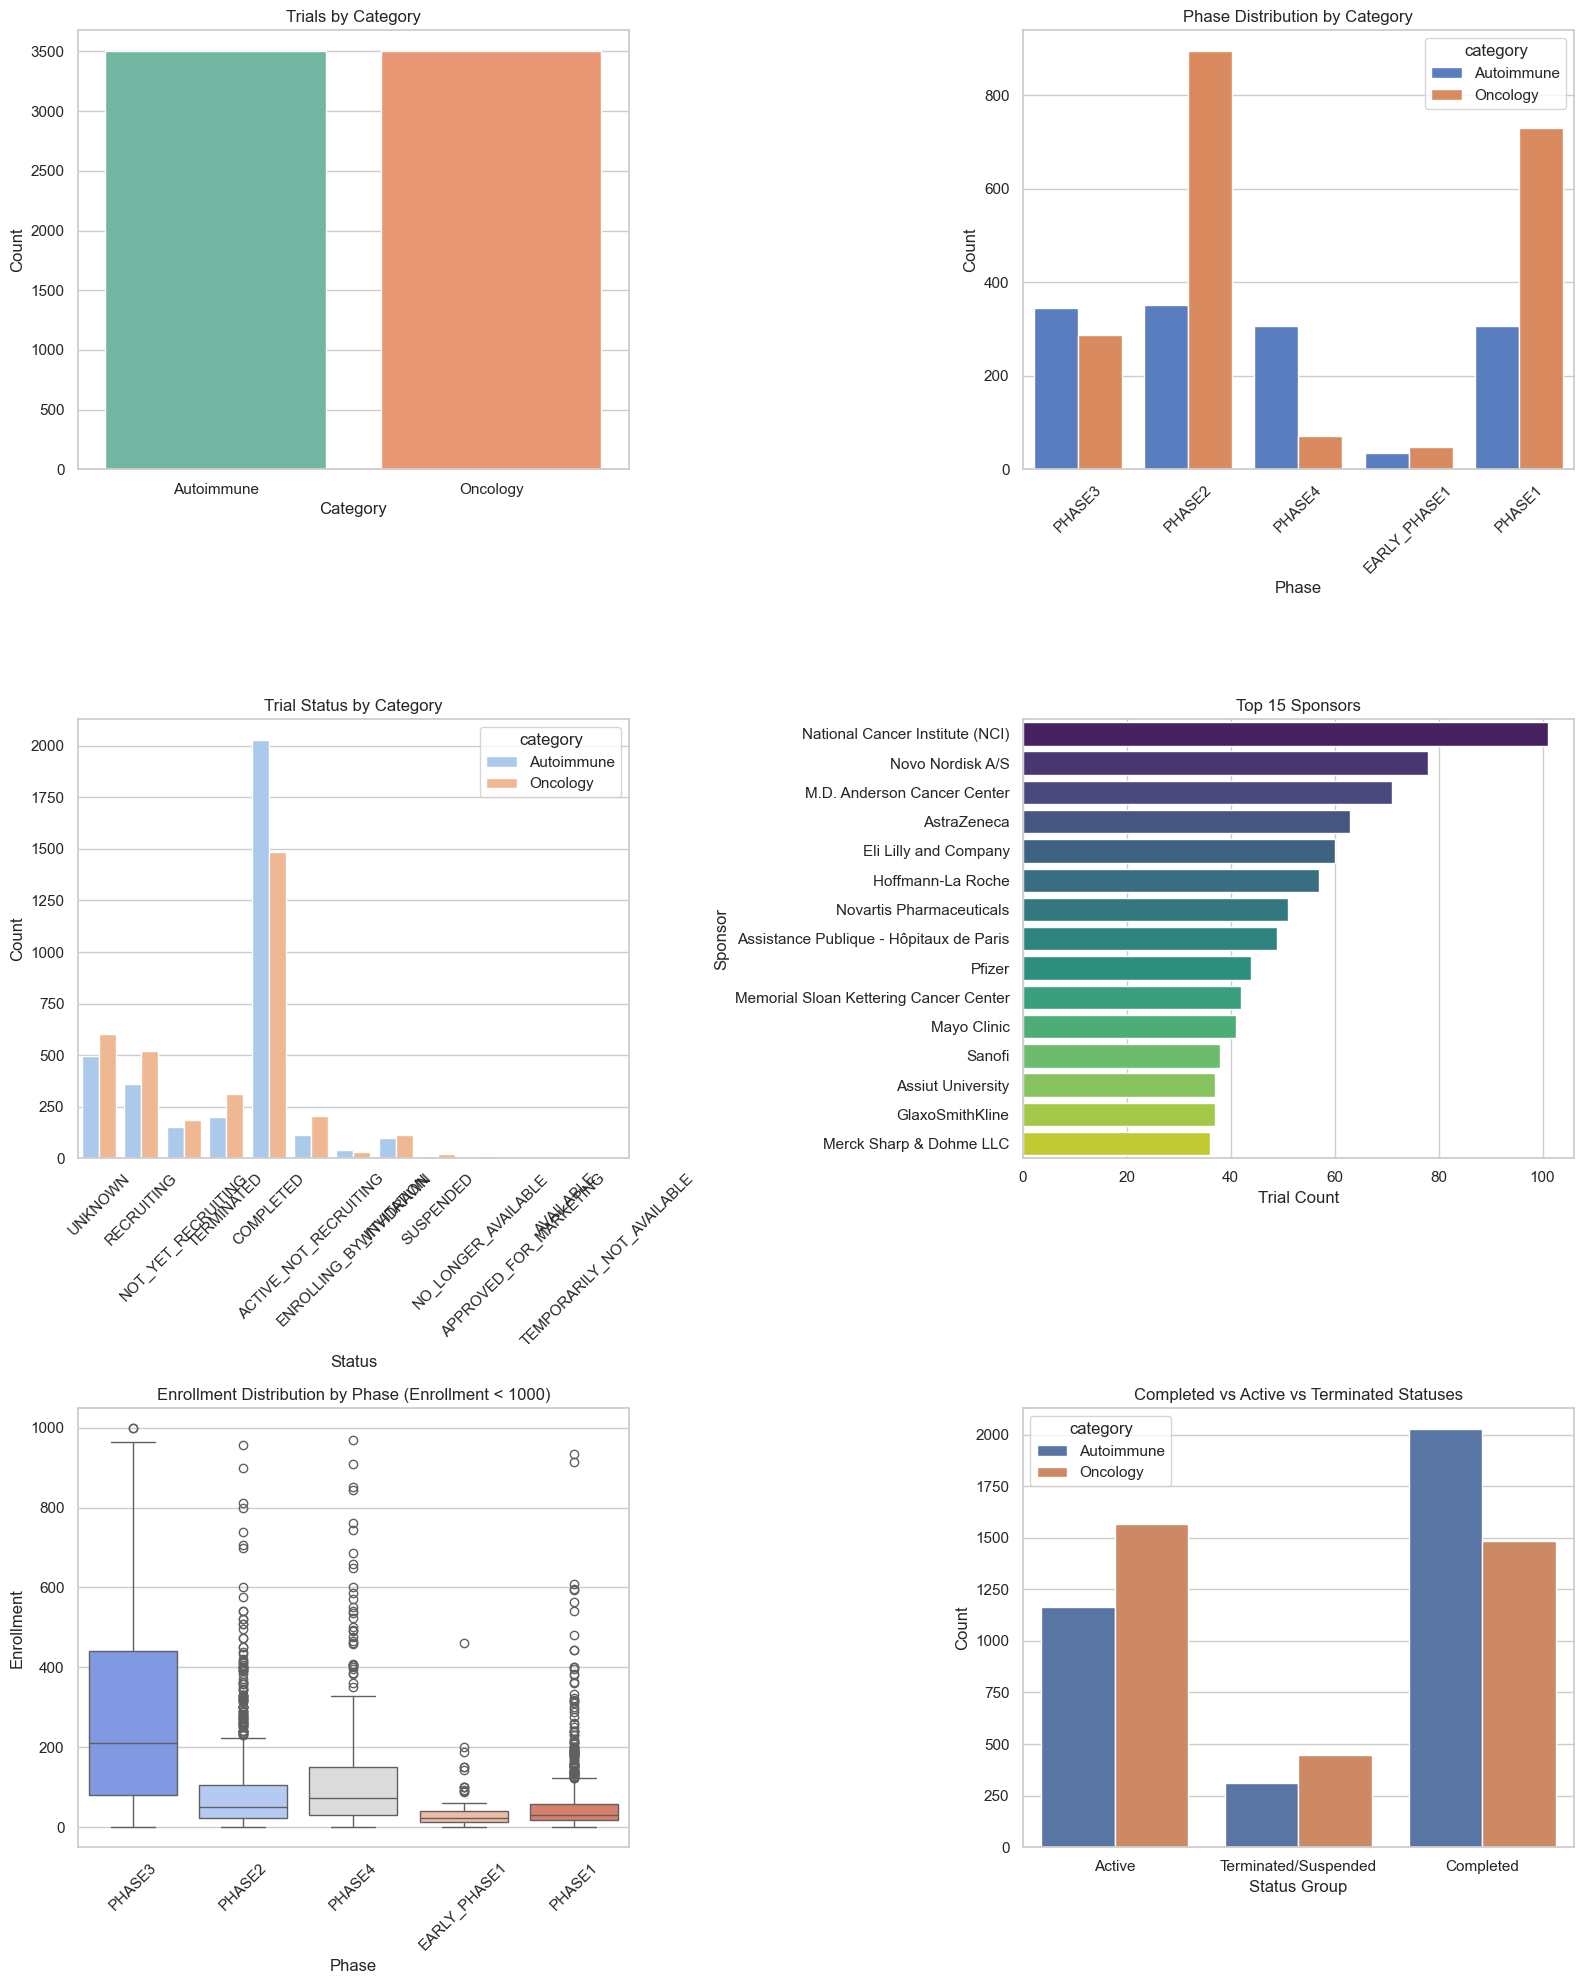

In [47]:
fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# 1. Trials by category
sns.countplot(data=df, x='category', ax=axes[0,0], hue='category', legend=False, palette='Set2')
axes[0,0].set_title('Trials by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Count')

# 2. Phase by category
sns.countplot(data=df, x='phase', hue='category', ax=axes[0,1], palette='muted')
axes[0,1].set_title('Phase Distribution by Category')
axes[0,1].set_xlabel('Phase')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Status by category
sns.countplot(data=df, x='status', hue='category', ax=axes[1,0], palette='pastel')
axes[1,0].set_title('Trial Status by Category')
axes[1,0].set_xlabel('Status')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Top 15 sponsors
top_sponsors = df['sponsor'].value_counts().head(15).reset_index()
sns.barplot(data=top_sponsors, y='sponsor', x='count', ax=axes[1,1], hue='sponsor', legend=False, palette='viridis')
axes[1,1].set_title('Top 15 Sponsors')
axes[1,1].set_xlabel('Trial Count')
axes[1,1].set_ylabel('Sponsor')

# 5. Enrollment by phase
df_temp = df.copy()
df_temp['enrollment'] = pd.to_numeric(df_temp['enrollment'], errors='coerce')
df_temp = df_temp[df_temp['enrollment'] < 1000]  # Filter extreme outliers for plotting
sns.boxplot(data=df_temp, x='phase', y='enrollment', ax=axes[2,0], hue='phase', palette='coolwarm', legend=False)
axes[2,0].set_title('Enrollment Distribution by Phase (Enrollment < 1000)')
axes[2,0].set_xlabel('Phase')
axes[2,0].set_ylabel('Enrollment')
axes[2,0].tick_params(axis='x', rotation=45)

# 6. Completed vs active vs terminated
df_status = df.copy()
df_status['status_class'] = 'Active'
df_status.loc[df_status['status'].fillna('').str.lower().str.contains('completed'), 'status_class'] = 'Completed'
df_status.loc[df_status['status'].fillna('').str.lower().str.contains('terminated|withdrawn|suspended'), 'status_class'] = 'Terminated/Suspended'
sns.countplot(data=df_status, x='status_class', hue='category', ax=axes[2,1], palette='deep')
axes[2,1].set_title('Completed vs Active vs Terminated Statuses')
axes[2,1].set_xlabel('Status Group')
axes[2,1].set_ylabel('Count')

plt.tight_layout()
plt.show()



# Why This Dynamic Analysis Layer Matters

The previous scoring layer gives a normalized quantitative comparison.  
The dynamic AI layer adds **explainability**.

Instead of relying only on hardcoded rules, MindReader can ask structured clinical questions for every trial:

- What exactly is being tested?
- Are the endpoints meaningful?
- Can efficacy be interpreted from available results?
- What safety and tolerability evidence exists?
- Is the therapy easy or difficult for patients?
- Is the study design strong or weak?
- What evidence is missing?
- What should users **not** conclude?
- What would change the interpretation?

This makes the system more flexible than a static scoring table while still keeping the AI **grounded in source data**.

---

# MindReader Differentiation

MindReader should not just summarize clinical trials. It should create:

1. **Trial Intelligence Cards**
2. **Dynamic Evidence Gap Reports**
3. **Patient Adoption Burden Analysis**
4. **Endpoint Meaningfulness Review**
5. **Red-Team Risk Review**
6. **Cross-Trial Comparative Interpretation**
7. **Data Confidence-Aware Summaries**
8. **AI-Discovered Dimension Extensions**

> The pipeline graph/tree comes later as the visual layer.  
> For now, the focus is **dynamic trial analysis**.


# Final Approval Summary

This notebook now demonstrates a clinically more defensible MindReader trial-analysis method.

It does not predict clinical success.

It compares selected clinical trials using:
- Deep registry parsing
- Results-section availability
- Adverse-event evidence availability
- Endpoint meaningfulness
- Study design quality
- Safety/tolerability interpretability
- Patient adoption burden
- Benchmark-cohort normalization
- Dynamic weighted scoring
- Data confidence scoring
- Rank-stability analysis
- Missing evidence matrix
- Evidence waterfall explanations
- Estimand-style trial question checks
- Source-grounded AI Trial Intelligence Cards
- Strict AI overclaim audit

This supports the product direction:

MindReader should become an explainable clinical-trial intelligence layer that helps users understand what a trial actually shows, what it does not show, what evidence is missing, and how studies compare under different stakeholder priorities.


In [ ]:
import os

os.makedirs("approval_outputs", exist_ok=True)

scored_df.to_csv("approval_outputs/final_scored_trials_with_confidence.csv", index=False)
rank_stability_df.to_csv("approval_outputs/rank_stability_analysis.csv", index=False)
rank_records_df.to_csv("approval_outputs/rank_stability_simulation_records.csv", index=False)
missing_matrix_df.to_csv("approval_outputs/missing_evidence_matrix.csv", index=False)
endpoint_meaningfulness_df.to_csv("approval_outputs/endpoint_meaningfulness_table.csv", index=False)

with open("approval_outputs/final_approval_summary.md", "w", encoding="utf-8") as f:
    f.write("# MindReader Final Approval Trial Analysis Summary\n\n")
    f.write("## Selected Trial Scores\n\n")
    f.write(scored_df[[
        "nct_id",
        "title",
        "sponsor",
        "balanced_view_score",
        "investor_view_score",
        "patient_view_score",
        "clinical_research_view_score",
        "regulatory_view_score",
        "data_confidence_score"
    ]].to_markdown(index=False))
    f.write("\n\n## Rank Stability\n\n")
    f.write(rank_stability_df.to_markdown(index=False))
    f.write("\n\n## Missing Evidence Matrix\n\n")
    f.write(missing_matrix_df.to_markdown(index=False))
    f.write("\n\n## Endpoint Meaningfulness\n\n")
    f.write(endpoint_meaningfulness_df.to_markdown(index=False))

print("Final approval outputs exported.")


Final approval outputs exported.
